# Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from scipy.stats import shapiro, normaltest
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, log_loss, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
)

from lightgbm import LGBMClassifier

from collections import defaultdict

/home/antonio/projetos/fase-5/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Funções úteis

### verificar_normalidade

In [2]:
def verificar_normalidade(data_series, feature_name, alpha=0.05):
    """
    Aplica os testes de Shapiro-Wilk e D'Agostino's K-squared a uma série de dados
    e imprime uma conclusão sobre sua normalidade.

    Args:
        data_series (pd.Series): A série de dados (coluna do DataFrame) a ser testada.
        feature_name (str): O nome da feature para impressão.
        alpha (float): O nível de significância para o teste.
    """
    print(f"--- Análise de Normalidade para a Feature: '{feature_name}' ---")

    # 1. Teste de Shapiro-Wilk
    stat_shapiro, p_shapiro = shapiro(data_series)
    print(f"\n1. Teste de Shapiro-Wilk:")
    print(f"   - Estatística do teste = {stat_shapiro:.4f}")
    print(f"   - P-valor = {p_shapiro:.4f}")
    if p_shapiro > alpha:
        print(f"   - Conclusão (alpha={alpha}): Não há evidência para rejeitar a normalidade (Normal).")
    else:
        print(f"   - Conclusão (alpha={alpha}): A hipótese de normalidade é rejeitada (Não Normal).")

    # 2. Teste de D'Agostino's K-squared
    stat_k2, p_k2 = normaltest(data_series)
    print(f"\n2. Teste de D'Agostino's K-squared:")
    print(f"   - Estatística do teste = {stat_k2:.4f}")
    print(f"   - P-valor = {p_k2:.4f}")
    if p_k2 > alpha:
        print(f"   - Conclusão (alpha={alpha}): Não há evidência para rejeitar a normalidade (Normal).")
    else:
        print(f"   - Conclusão (alpha={alpha}): A hipótese de normalidade é rejeitada (Não Normal).")

    print("-" * 50 + "\n")

### aplicar_transformacao_log

In [3]:
def aplicar_transformacao_log(df, colunas):
    """
    Aplica a transformação logarítmica (log1p) a uma lista de colunas
    de um DataFrame e cria novas colunas com o sufixo '_log'.

    Args:
        df (pd.DataFrame): O DataFrame de entrada.
        colunas (list): Uma lista de nomes de colunas para transformar.

    Returns:
        pd.DataFrame: O DataFrame com as novas colunas transformadas.
    """
    df_transformado = df.copy()
    #new_columns = []
    for col in colunas:
        # Verifica se a coluna existe no DataFrame
        if col in df_transformado.columns:
            df_transformado[col + '_log'] = np.log1p(df_transformado[col])
            #new_columns.append(col + '_log')
        else:
            print(f"Aviso: A coluna '{col}' não foi encontrada no DataFrame.")

    return df_transformado

### perform_cross_validation

In [4]:
def perform_cross_validation(X_train, y_train, skf, model):
    """
    Realiza validação cruzada estratificada para CLASSIFICAÇÃO BINÁRIA.

    Para cada fold, treina o modelo fornecido com escalonamento de features,
    calcula predições e probabilidades, e retorna um dicionário com as métricas
    de desempenho tanto para o conjunto de treino quanto para o de validação.

    Parameters
    ----------
    X_train : pd.DataFrame or np.ndarray
        Features do conjunto de treinamento.
    y_train : pd.Series or np.ndarray
        Labels do conjunto de treinamento (binários: 0 ou 1).
        Classe positiva (1) representa evasão do aluno.
    skf : StratifiedKFold
        Objeto StratifiedKFold configurado.
    model : estimator object
        Instância do modelo de classificação a ser treinado.

    Returns
    -------
    results : dict
        Dicionário contendo as listas de métricas calculadas para cada fold.
        Estrutura: results[dataset][metric] = [valores por fold]
    """
    
    # Dicionário para armazenar os resultados
    results = defaultdict(lambda: defaultdict(list))
    
    n_splits = skf.get_n_splits()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        print(f"\n{'='*60}")
        print(f"Processando Fold {fold}/{n_splits}")
        print(f"{'='*60}")

        # Divisão dos dados do fold (usando indexação que funciona para pandas e numpy)
        if isinstance(X_train, pd.DataFrame):
            X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        else:
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]

        if isinstance(y_train, pd.Series):
            y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        else:
            y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        # Escalonamento das features
        scaler = StandardScaler()
        
        if isinstance(X_train, pd.DataFrame):
            X_train_fold_scaled = pd.DataFrame(
                scaler.fit_transform(X_train_fold),
                columns=X_train_fold.columns,
                index=X_train_fold.index
            )
            X_val_fold_scaled = pd.DataFrame(
                scaler.transform(X_val_fold),
                columns=X_val_fold.columns,
                index=X_val_fold.index
            )
        else:
            X_train_fold_scaled = scaler.fit_transform(X_train_fold)
            X_val_fold_scaled = scaler.transform(X_val_fold)

        # Treinamento do modelo
        model.fit(X_train_fold_scaled, y_train_fold)

        # Predições e Probabilidades
        datasets = {
            'train': (y_train_fold, X_train_fold_scaled),
            'validation': (y_val_fold, X_val_fold_scaled)
        }

        # Cálculo e Armazenamento das Métricas
        for name, (y_true, X_scaled) in datasets.items():
            # Predições
            y_pred = model.predict(X_scaled)
            y_proba = model.predict_proba(X_scaled)
            
            # Para classificação binária: extrair probabilidade da classe positiva (coluna 1)
            y_proba_pos = y_proba[:, 1]

            # Calculando as métricas para classificação binária
            acc = accuracy_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred, pos_label=1)
            recall = recall_score(y_true, y_pred, pos_label=1)
            precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            loss = log_loss(y_true, y_proba)  # Log loss (menor é melhor)
            roc = roc_auc_score(y_true, y_proba_pos)  # ROC-AUC binário
            pr_auc = average_precision_score(y_true, y_proba_pos)  # PR-AUC binário

            # Armazenando os resultados
            results[name]['accuracy'].append(acc)
            results[name]['f1_score'].append(f1)
            results[name]['recall'].append(recall)
            results[name]['precision'].append(precision)
            results[name]['log_loss'].append(loss)
            results[name]['roc_auc'].append(roc)
            results[name]['pr_auc'].append(pr_auc)
        
        # Exibir métricas do fold atual
        print(f"\nTrain      - Acc: {results['train']['accuracy'][-1]:.4f} | "
              f"F1: {results['train']['f1_score'][-1]:.4f} | "
              f"ROC-AUC: {results['train']['roc_auc'][-1]:.4f}")
        print(f"Validation - Acc: {results['validation']['accuracy'][-1]:.4f} | "
              f"F1: {results['validation']['f1_score'][-1]:.4f} | "
              f"ROC-AUC: {results['validation']['roc_auc'][-1]:.4f}")

    print(f"\n{'='*60}")
    print("✅ Validação Cruzada concluída!")
    print(f"{'='*60}")
    
    return dict(results)

# Loading data

In [5]:
data_dir = '../data/processed'
file_name_2022 = 'df_model_2022.csv'
file_path_2022 = os.path.join(data_dir, file_name_2022)

file_name_2023 = 'df_model_2023.csv'
file_path_2023 = os.path.join(data_dir, file_name_2023)

file_name_concatenado = 'df_model_concatenado.csv'
file_path_concatenado = os.path.join(data_dir, file_name_concatenado)

df_loaded = pd.read_csv(file_path_2022)
df_loaded.head()

,RA,FASE_22,TURMA_22,DEFASAGEM_22,NOVA_FASE_IDEAL_22,IDADE_2022,GÊNERO_22,ANO_INGRESSO_22,INSTITUICAO_ENSINO_22,VETERANO_22,EM_FASE_22,QTDE_AVAL_2022,IAA_22,IEG_22,IPS_22,IDA_22,IPV_22,IAN_22,EVADIU
0,RA-1,Fase 7,A,-1.0,Fase 8,19.0,1.0,2016.0,Pública,1.0,0.0,4.0,8.3,4.1,5.6,4.0,7.278,5.0,0.0
1,RA-10,Fase 7,A,-1.0,Fase 8,18.0,1.0,2021.0,Pública,1.0,0.0,4.0,8.3,5.2,5.0,4.1,7.056,5.0,1.0
2,RA-100,Fase 4,A,1.0,Fase 3,13.0,1.0,2019.0,Privada,1.0,0.0,4.0,8.8,7.8,5.0,7.6,7.250,10.0,1.0
3,RA-101,Fase 4,A,-1.0,Fase 5,15.0,1.0,2021.0,Pública,1.0,0.0,4.0,7.9,8.3,7.5,7.6,6.833,5.0,1.0
4,RA-102,Fase 4,A,0.0,Fase 4,14.0,0.0,2019.0,Pública,1.0,1.0,4.0,6.7,7.7,6.9,5.7,6.000,10.0,1.0


In [6]:
df_loaded.info()

<class 'pandas.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    str    
 1   FASE_22                860 non-null    str    
 2   TURMA_22               860 non-null    str    
 3   DEFASAGEM_22           860 non-null    float64
 4   NOVA_FASE_IDEAL_22     860 non-null    str    
 5   IDADE_2022             860 non-null    float64
 6   GÊNERO_22              860 non-null    float64
 7   ANO_INGRESSO_22        860 non-null    float64
 8   INSTITUICAO_ENSINO_22  860 non-null    str    
 9   VETERANO_22            860 non-null    float64
 10  EM_FASE_22             860 non-null    float64
 11  QTDE_AVAL_2022         860 non-null    float64
 12  IAA_22                 860 non-null    float64
 13  IEG_22                 860 non-null    float64
 14  IPS_22                 860 non-null    float64
 15  IDA_22           

## numerical and categorical features

In [7]:
target = df_loaded[['EVADIU']].astype('int64')
num_features = df_loaded.select_dtypes(['float64','int64']).drop(columns=['EVADIU']).columns.tolist()
categorical_features = df_loaded.select_dtypes(['object','category','str']).columns.tolist()

In [8]:
df_loaded[num_features].head()

,DEFASAGEM_22,IDADE_2022,GÊNERO_22,ANO_INGRESSO_22,VETERANO_22,EM_FASE_22,QTDE_AVAL_2022,IAA_22,IEG_22,IPS_22,IDA_22,IPV_22,IAN_22
0,-1.0,19.0,1.0,2016.0,1.0,0.0,4.0,8.3,4.1,5.6,4.0,7.278,5.0
1,-1.0,18.0,1.0,2021.0,1.0,0.0,4.0,8.3,5.2,5.0,4.1,7.056,5.0
2,1.0,13.0,1.0,2019.0,1.0,0.0,4.0,8.8,7.8,5.0,7.6,7.250,10.0
3,-1.0,15.0,1.0,2021.0,1.0,0.0,4.0,7.9,8.3,7.5,7.6,6.833,5.0
4,0.0,14.0,0.0,2019.0,1.0,1.0,4.0,6.7,7.7,6.9,5.7,6.000,10.0


In [9]:
df_loaded[categorical_features].head()

,RA,FASE_22,TURMA_22,NOVA_FASE_IDEAL_22,INSTITUICAO_ENSINO_22
0,RA-1,Fase 7,A,Fase 8,Pública
1,RA-10,Fase 7,A,Fase 8,Pública
2,RA-100,Fase 4,A,Fase 3,Privada
3,RA-101,Fase 4,A,Fase 5,Pública
4,RA-102,Fase 4,A,Fase 4,Pública


In [10]:
df_loaded[categorical_features]['FASE_22'].value_counts()

FASE_22
Fase 1    192
Fase 0    190
Fase 2    155
Fase 3    148
Fase 4     76
Fase 5     60
Fase 7     21
Fase 6     18
Name: count, dtype: int64

In [11]:
df_loaded[categorical_features]['NOVA_FASE_IDEAL_22'].value_counts()

NOVA_FASE_IDEAL_22
Fase 2    218
Fase 3    207
Fase 1     96
Fase 4     85
Fase 0     71
Fase 5     63
Fase 6     52
Fase 7     48
Fase 8     20
Name: count, dtype: int64

In [12]:
df_loaded[categorical_features]['INSTITUICAO_ENSINO_22'].value_counts()

INSTITUICAO_ENSINO_22
Pública    752
Privada    108
Name: count, dtype: int64

In [13]:
df_loaded[categorical_features]['TURMA_22'].value_counts()

TURMA_22
A    107
B     78
L     76
F     70
K     62
D     49
M     47
G     40
J     38
U     38
P     33
N     32
C     29
H     25
E     23
Q     22
I     20
R     20
O     12
Y     10
Z      9
S      7
V      7
T      6
Name: count, dtype: int64

# Tratamento de dados inicial

## Feature 'INSTITUICAO_ENSINO_22'

In [14]:
map_instituicao = {'Pública' : 1,
                   'Privada': 0}
df_loaded['INSTITUICAO_ENSINO_22_mapped'] = df_loaded['INSTITUICAO_ENSINO_22'].map(map_instituicao)
df_loaded['INSTITUICAO_ENSINO_22_mapped'].value_counts()


INSTITUICAO_ENSINO_22_mapped
1    752
0    108
Name: count, dtype: int64

## Amostras duplicadas

In [15]:
# Identificando presença de valores repetidos
df_loaded[df_loaded.duplicated()]

,RA,FASE_22,TURMA_22,DEFASAGEM_22,NOVA_FASE_IDEAL_22,IDADE_2022,GÊNERO_22,ANO_INGRESSO_22,INSTITUICAO_ENSINO_22,VETERANO_22,EM_FASE_22,QTDE_AVAL_2022,IAA_22,IEG_22,IPS_22,IDA_22,IPV_22,IAN_22,EVADIU,INSTITUICAO_ENSINO_22_mapped


# Análise Exploratória de Dados (EDA)

In [16]:
num_features = df_loaded.select_dtypes(['float64','int64']).drop(columns=['EVADIU']).columns.tolist()
df_loaded[num_features].describe([.1, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
DEFASAGEM_22,860.0,-0.943023,0.845593,-5.0,-2.000,-1.000,-1.000,0.000,0.0,0.000,1.00000,2.0
IDADE_2022,860.0,12.138372,2.771998,7.0,9.000,10.000,12.000,14.000,16.0,17.000,18.00000,21.0
GÊNERO_22,860.0,0.531395,0.499304,0.0,0.000,0.000,1.000,1.000,1.0,1.000,1.00000,1.0
ANO_INGRESSO_22,860.0,2020.496512,1.790217,2016.0,2018.000,2019.000,2021.000,2022.000,2022.0,2022.000,2022.00000,2022.0
VETERANO_22,860.0,0.536047,0.498989,0.0,0.000,0.000,1.000,1.000,1.0,1.000,1.00000,1.0
EM_FASE_22,860.0,0.287209,0.452723,0.0,0.000,0.000,0.000,1.000,1.0,1.000,1.00000,1.0
QTDE_AVAL_2022,860.0,3.054651,0.775371,2.0,2.000,2.000,3.000,4.000,4.0,4.000,4.00000,4.0
IAA_22,860.0,8.274419,2.064935,0.0,6.900,7.900,8.800,9.500,10.0,10.000,10.00000,10.0
IEG_22,860.0,7.891163,1.638340,0.0,5.590,7.000,8.300,9.100,9.6,9.800,10.00000,10.0
IPS_22,860.0,6.905000,1.070707,2.5,5.000,6.300,7.500,7.500,7.5,8.100,9.04600,10.0


## Análise univariada

### Feature DEFASAGEM_22

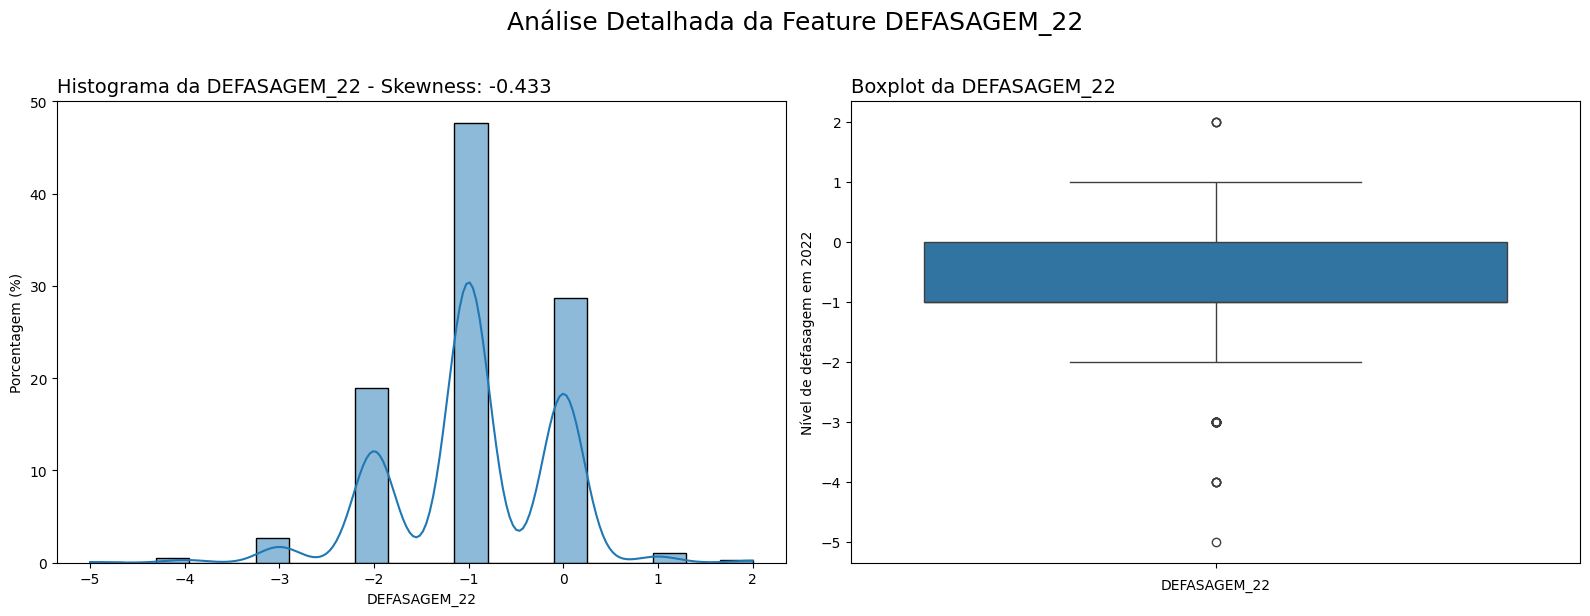

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['DEFASAGEM_22'].skew()

# Histograma
sns.histplot(df_loaded['DEFASAGEM_22'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da DEFASAGEM_22 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('DEFASAGEM_22')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['DEFASAGEM_22'], ax=axes[1])
axes[1].set_title('Boxplot da DEFASAGEM_22', fontsize=14, loc='left')
axes[1].set_ylabel('Nível de defasagem em 2022')
axes[1].set_xlabel('DEFASAGEM_22')

plt.suptitle('Análise Detalhada da Feature DEFASAGEM_22', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['DEFASAGEM_22'], 'DEFASAGEM_22')

--- Análise de Normalidade para a Feature: 'DEFASAGEM_22' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.8639
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 45.0236
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IDADE_2022

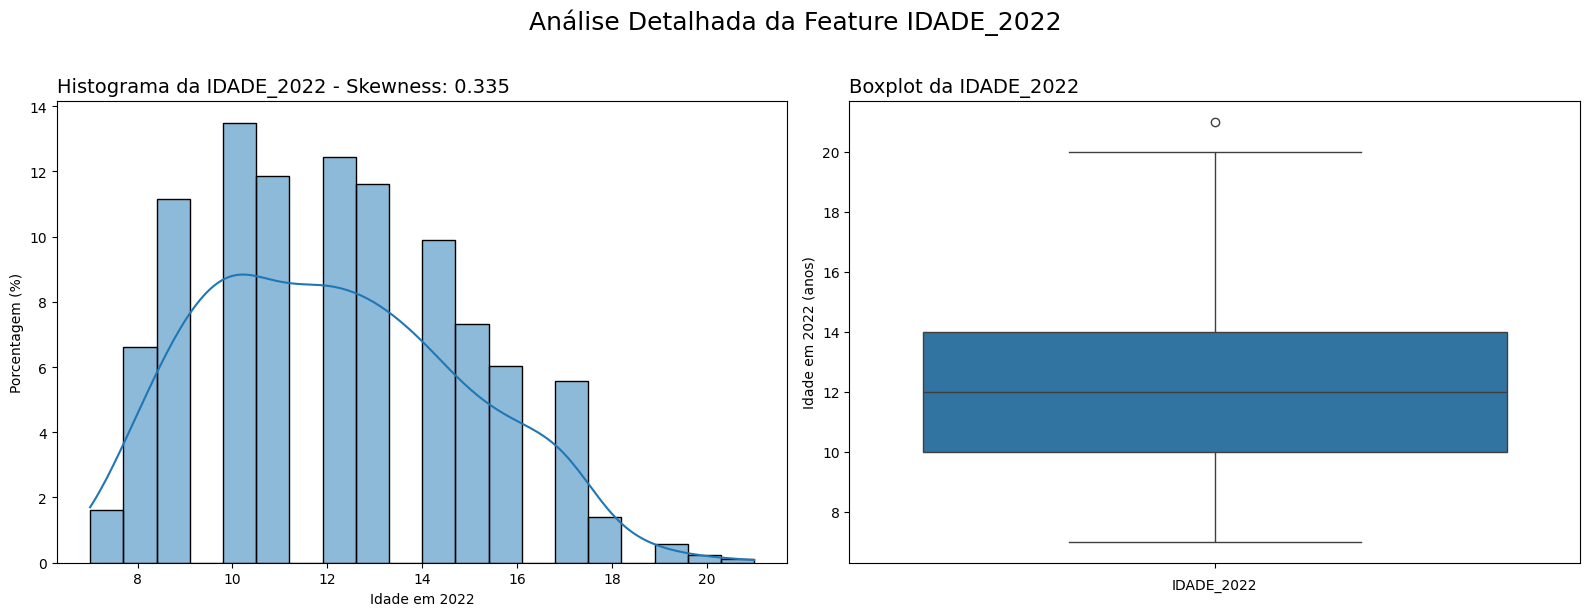

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IDADE_2022'].skew()

# Histograma
sns.histplot(df_loaded['IDADE_2022'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IDADE_2022 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('Idade em 2022')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IDADE_2022'], ax=axes[1])
axes[1].set_title('Boxplot da IDADE_2022', fontsize=14, loc='left')
axes[1].set_ylabel('Idade em 2022 (anos)')
axes[1].set_xlabel('IDADE_2022')

plt.suptitle('Análise Detalhada da Feature IDADE_2022', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IDADE_2022'], 'IDADE_2022')

--- Análise de Normalidade para a Feature: 'IDADE_2022' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.9678
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 43.1646
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature ANO_INGRESSO_22

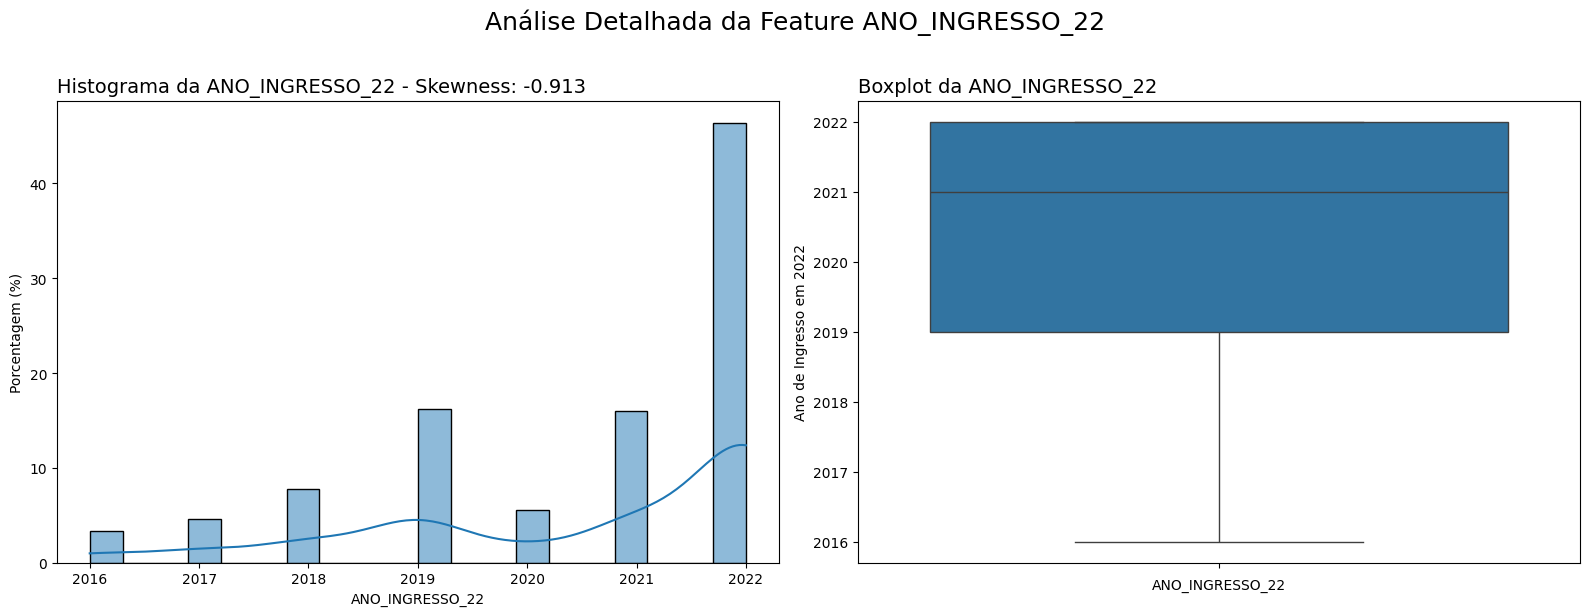

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['ANO_INGRESSO_22'].skew()

# Histograma
sns.histplot(df_loaded['ANO_INGRESSO_22'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da ANO_INGRESSO_22 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('ANO_INGRESSO_22')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['ANO_INGRESSO_22'], ax=axes[1])
axes[1].set_title('Boxplot da ANO_INGRESSO_22', fontsize=14, loc='left')
axes[1].set_ylabel('Ano de Ingresso em 2022')
axes[1].set_xlabel('ANO_INGRESSO_22')

plt.suptitle('Análise Detalhada da Feature ANO_INGRESSO_22', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['ANO_INGRESSO_22'], 'ANO_INGRESSO_22')

--- Análise de Normalidade para a Feature: 'ANO_INGRESSO_22' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.7992
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 97.1401
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature QTDE_AVAL_2022

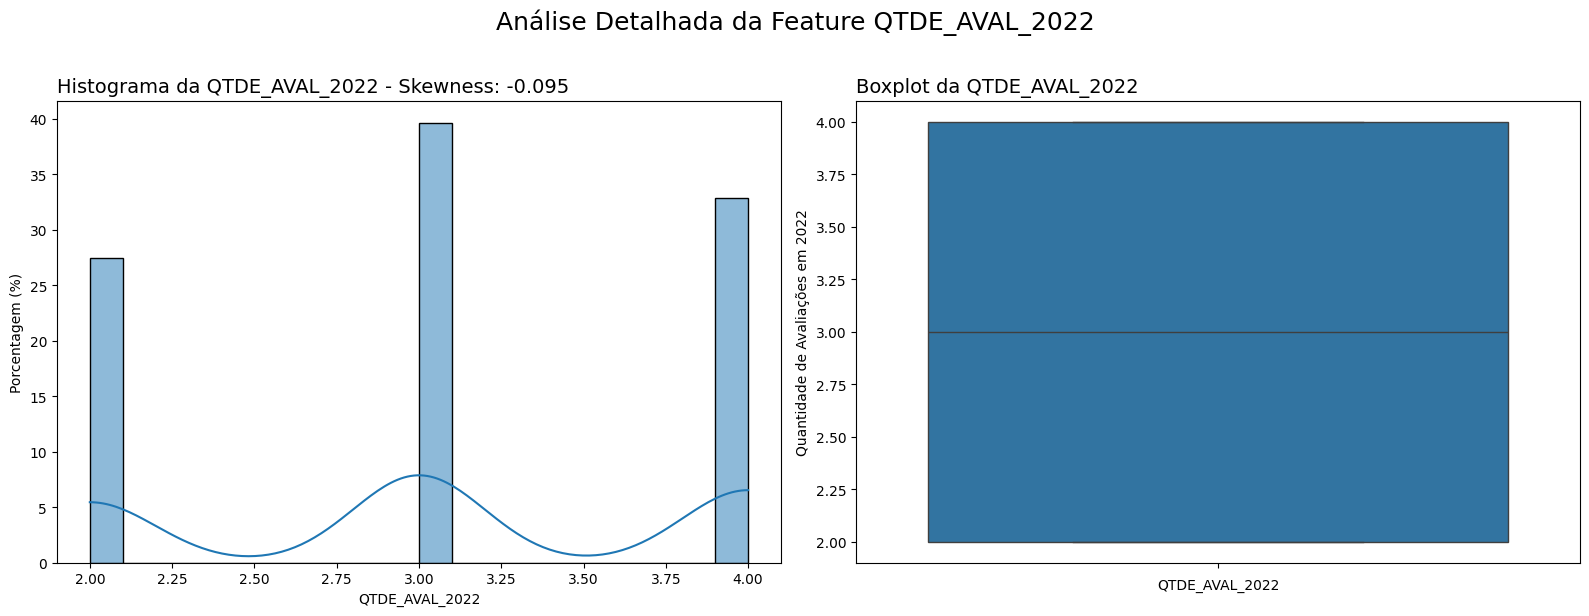

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['QTDE_AVAL_2022'].skew()

# Histograma
sns.histplot(df_loaded['QTDE_AVAL_2022'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da QTDE_AVAL_2022 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('QTDE_AVAL_2022')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['QTDE_AVAL_2022'], ax=axes[1])
axes[1].set_title('Boxplot da QTDE_AVAL_2022', fontsize=14, loc='left')
axes[1].set_ylabel('Quantidade de Avaliações em 2022')
axes[1].set_xlabel('QTDE_AVAL_2022')

plt.suptitle('Análise Detalhada da Feature QTDE_AVAL_2022', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['QTDE_AVAL_2022'], 'QTDE_AVAL_2022')

--- Análise de Normalidade para a Feature: 'QTDE_AVAL_2022' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.8044
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 3011.4316
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IAA_22

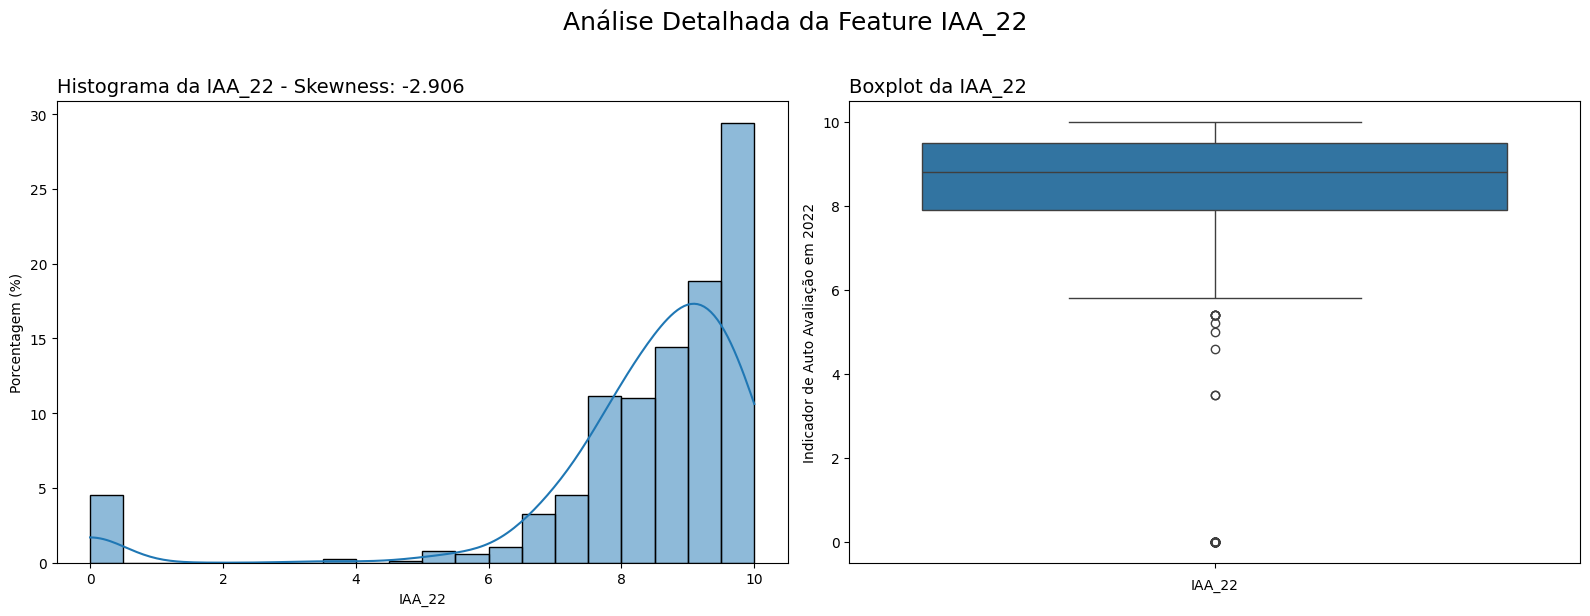

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IAA_22'].skew()

# Histograma
sns.histplot(df_loaded['IAA_22'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IAA_22 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IAA_22')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IAA_22'], ax=axes[1])
axes[1].set_title('Boxplot da IAA_22', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador de Auto Avaliação em 2022')
axes[1].set_xlabel('IAA_22')

plt.suptitle('Análise Detalhada da Feature IAA_22', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IAA_22'], 'IAA_22')

--- Análise de Normalidade para a Feature: 'IAA_22' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.6439
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 538.1683
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IEG_22

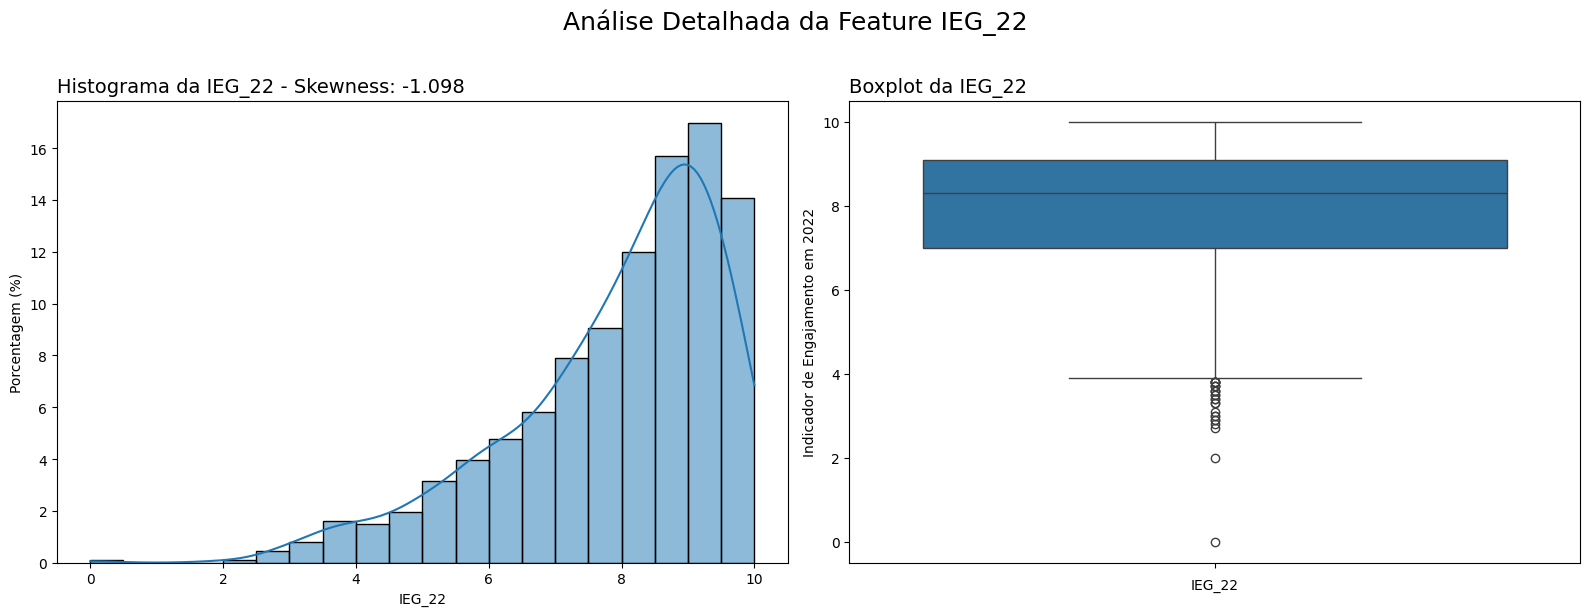

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IEG_22'].skew()

# Histograma
sns.histplot(df_loaded['IEG_22'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IEG_22 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IEG_22')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IEG_22'], ax=axes[1])
axes[1].set_title('Boxplot da IEG_22', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador de Engajamento em 2022')
axes[1].set_xlabel('IEG_22')

plt.suptitle('Análise Detalhada da Feature IEG_22', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IEG_22'], 'IEG_22')

--- Análise de Normalidade para a Feature: 'IEG_22' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.9113
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 136.4280
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IPS_22

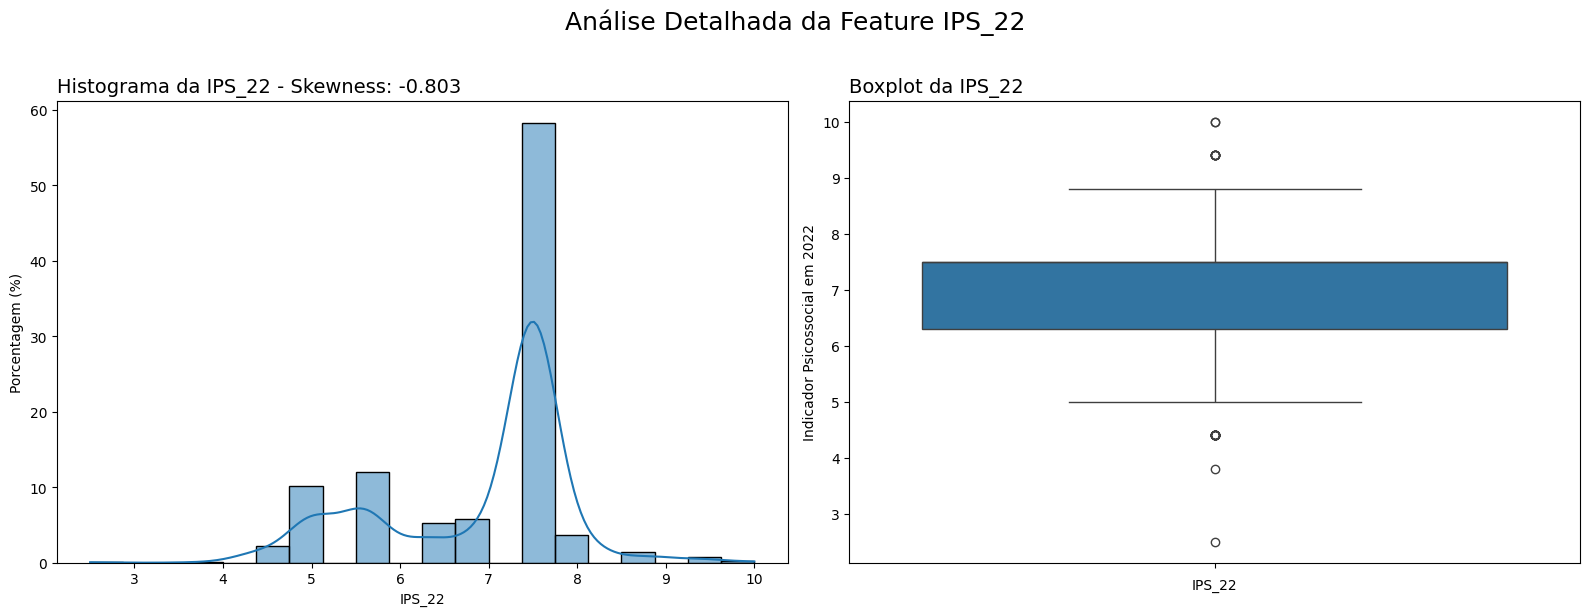

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IPS_22'].skew()

# Histograma
sns.histplot(df_loaded['IPS_22'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IPS_22 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IPS_22')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IPS_22'], ax=axes[1])
axes[1].set_title('Boxplot da IPS_22', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador Psicossocial em 2022')
axes[1].set_xlabel('IPS_22')

plt.suptitle('Análise Detalhada da Feature IPS_22', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [30]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IPS_22'], 'IPS_22')

--- Análise de Normalidade para a Feature: 'IPS_22' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.7942
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 73.7061
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IDA_22

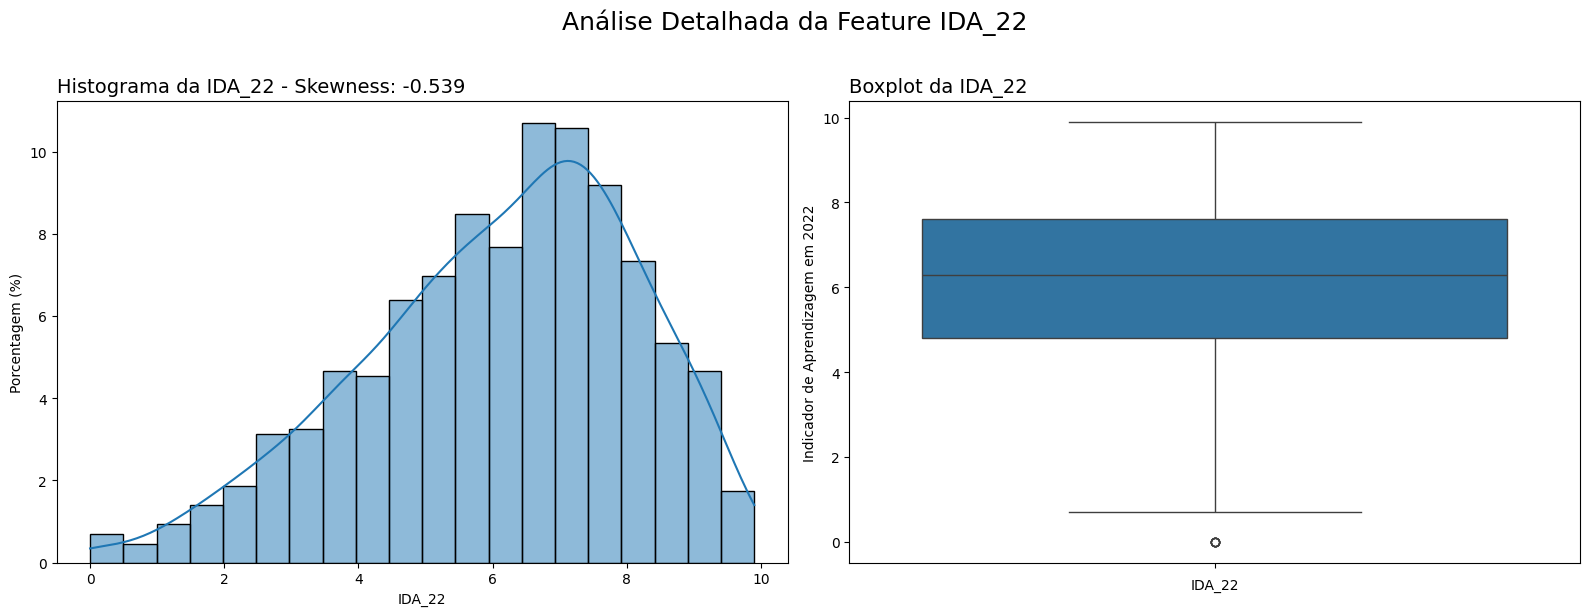

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IDA_22'].skew()

# Histograma
sns.histplot(df_loaded['IDA_22'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IDA_22 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IDA_22')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IDA_22'], ax=axes[1])
axes[1].set_title('Boxplot da IDA_22', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador de Aprendizagem em 2022')
axes[1].set_xlabel('IDA_22')

plt.suptitle('Análise Detalhada da Feature IDA_22', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [32]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IDA_22'], 'IDA_22')

--- Análise de Normalidade para a Feature: 'IDA_22' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.9724
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 39.1084
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IPV_22

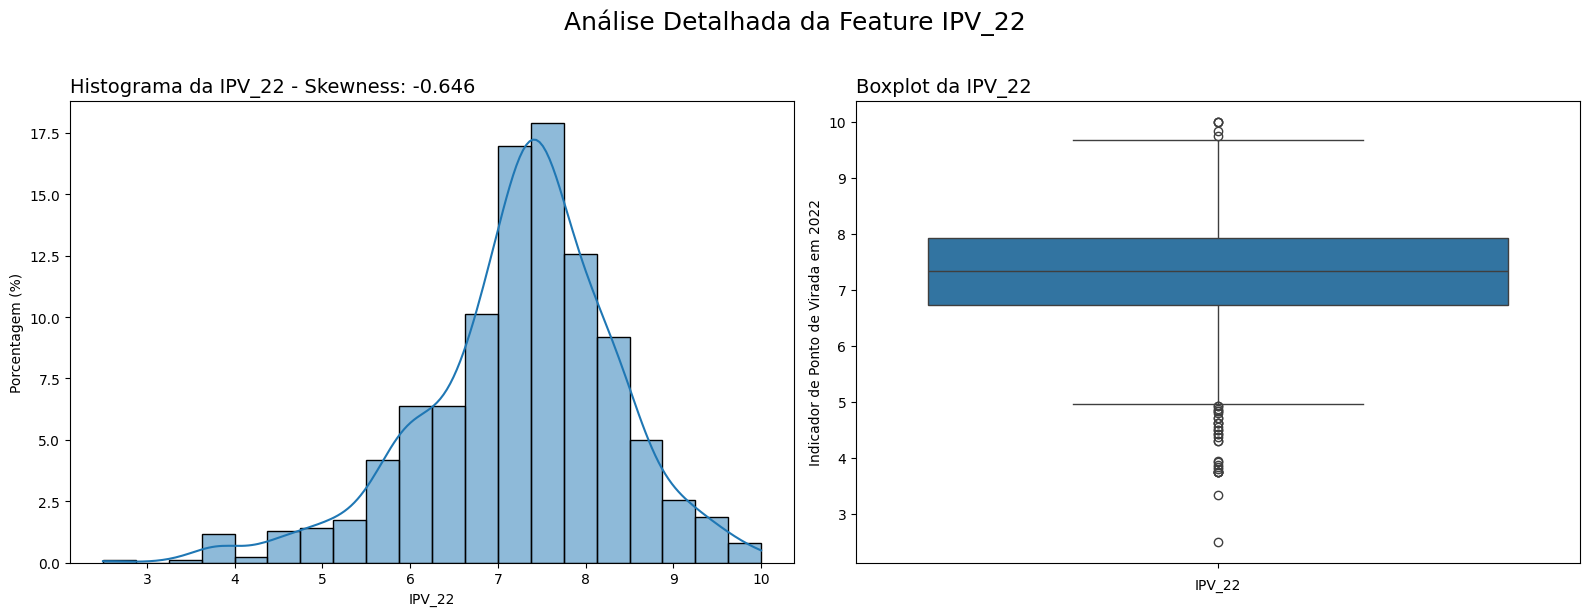

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IPV_22'].skew()

# Histograma
sns.histplot(df_loaded['IPV_22'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IPV_22 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IPV_22')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IPV_22'], ax=axes[1])
axes[1].set_title('Boxplot da IPV_22', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador de Ponto de Virada em 2022')
axes[1].set_xlabel('IPV_22')

plt.suptitle('Análise Detalhada da Feature IPV_22', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IPV_22'], 'IPV_22')

--- Análise de Normalidade para a Feature: 'IPV_22' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.9721
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 72.6823
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature IAN_22

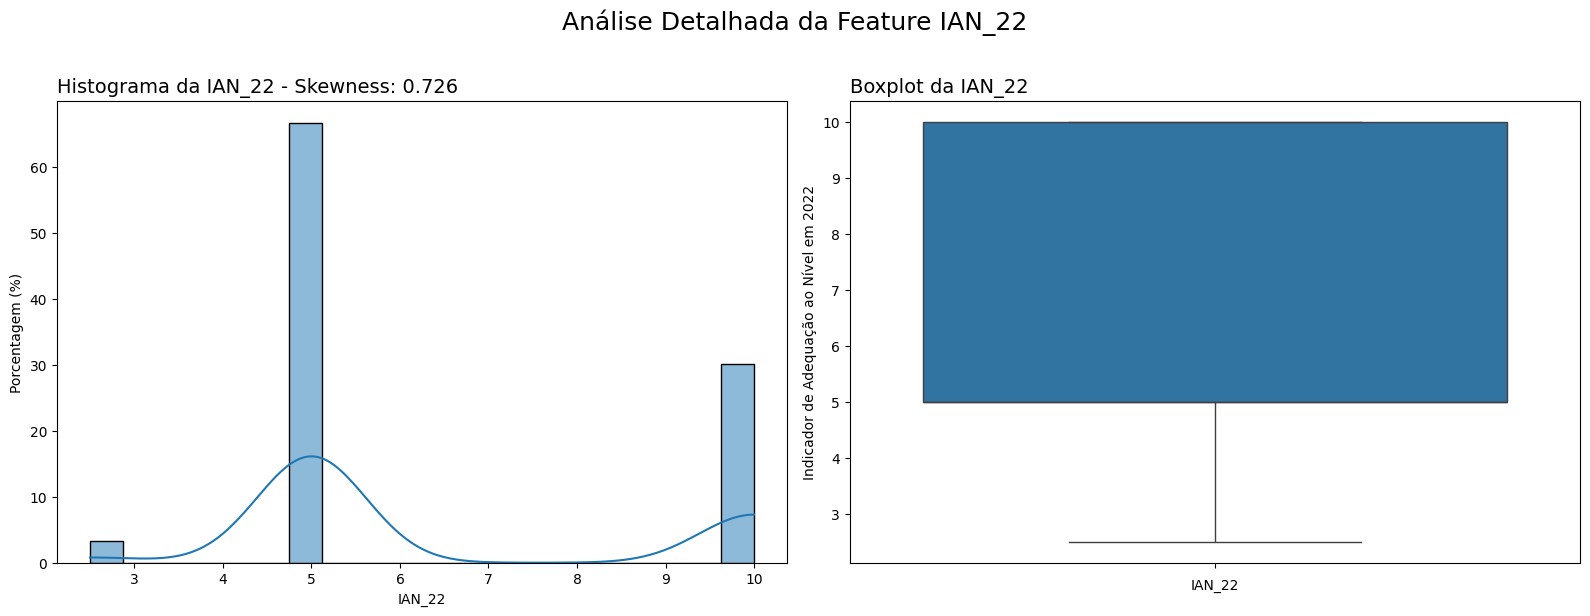

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculando a skewness
skewness = df_loaded['IAN_22'].skew()

# Histograma
sns.histplot(df_loaded['IAN_22'], kde=True, ax=axes[0], bins=20, stat='percent')
axes[0].set_title(f'Histograma da IAN_22 - Skewness: {skewness:.3f}', fontsize=14, loc='left')
axes[0].set_xlabel('IAN_22')
axes[0].set_ylabel('Porcentagem (%)')

# Boxplot
sns.boxplot(y=df_loaded['IAN_22'], ax=axes[1])
axes[1].set_title('Boxplot da IAN_22', fontsize=14, loc='left')
axes[1].set_ylabel('Indicador de Adequação ao Nível em 2022')
axes[1].set_xlabel('IAN_22')

plt.suptitle('Análise Detalhada da Feature IAN_22', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [36]:
# Análise da normalidade da feature

verificar_normalidade(df_loaded['IAN_22'], 'IAN_22')

--- Análise de Normalidade para a Feature: 'IAN_22' ---

1. Teste de Shapiro-Wilk:
   - Estatística do teste = 0.6486
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).

2. Teste de D'Agostino's K-squared:
   - Estatística do teste = 538.5421
   - P-valor = 0.0000
   - Conclusão (alpha=0.05): A hipótese de normalidade é rejeitada (Não Normal).
--------------------------------------------------



### Feature VETERANO_22

In [37]:
order_by_label = df_loaded['VETERANO_22'].value_counts().index
class_counts = df_loaded['VETERANO_22'].value_counts()

class_percentages = (df_loaded['VETERANO_22'].value_counts(normalize=True, ) * 100).round(2)
print(class_percentages)

VETERANO_22
1.0    53.6
0.0    46.4
Name: proportion, dtype: float64


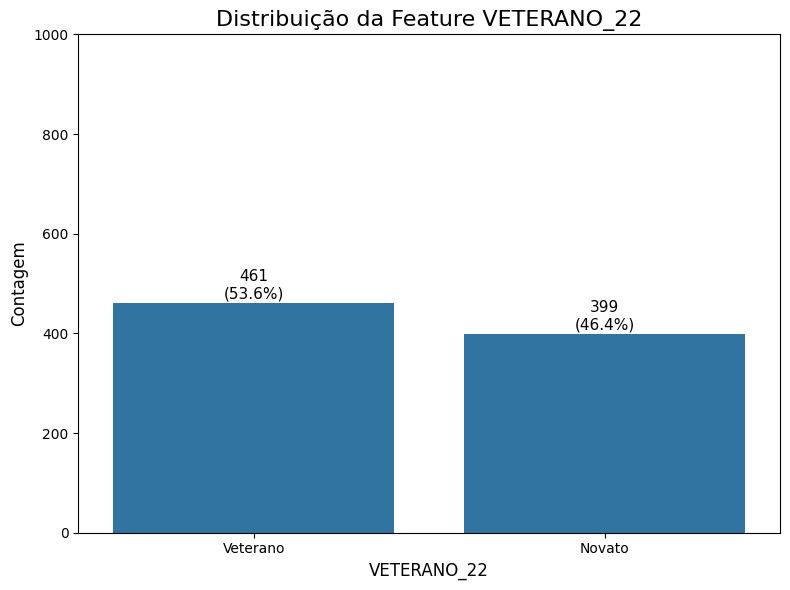

In [38]:
df = df_loaded['VETERANO_22'].copy()

# Mapear valores numéricos para labels
gender_map = {1: 'Veterano', 0: 'Novato'}
df_plot = pd.DataFrame(df).copy()
df_plot['VETERANO_LABEL'] = df_plot['VETERANO_22'].map(gender_map)

# Definir ordem (opcional - ajuste conforme necessário)
order_labels = ['Veterano', 'Novato']

# Visualização da distribuição da feature
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='VETERANO_LABEL', data=df_plot, order=order_labels)

plt.title('Distribuição da Feature VETERANO_22', fontsize=16)
plt.xlabel('VETERANO_22', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.ylim(0, 1000)

# Adicionando rótulos
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Feature EM_FASE_22

In [39]:
order_by_label = df_loaded['EM_FASE_22'].value_counts().index
class_counts = df_loaded['EM_FASE_22'].value_counts()

class_percentages = (df_loaded['EM_FASE_22'].value_counts(normalize=True, ) * 100).round(2)
print(class_percentages)

EM_FASE_22
0.0    71.28
1.0    28.72
Name: proportion, dtype: float64


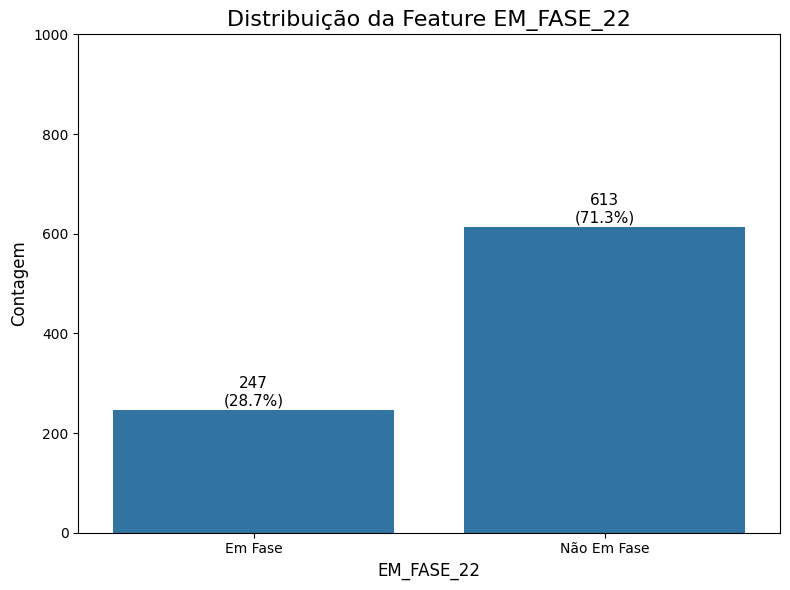

In [40]:
df = df_loaded['EM_FASE_22'].copy()

# Mapear valores numéricos para labels
gender_map = {1: 'Em Fase', 0: 'Não Em Fase'}
df_plot = pd.DataFrame(df).copy()
df_plot['EM_FASE_LABEL'] = df_plot['EM_FASE_22'].map(gender_map)

# Definir ordem (opcional - ajuste conforme necessário)
order_labels = ['Em Fase', 'Não Em Fase']

# Visualização da distribuição da feature
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='EM_FASE_LABEL', data=df_plot, order=order_labels)

plt.title('Distribuição da Feature EM_FASE_22', fontsize=16)
plt.xlabel('EM_FASE_22', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.ylim(0, 1000)

# Adicionando rótulos
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Feature INSTITUICAO_ENSINO_22_mapped

In [41]:
order_by_label = df_loaded['INSTITUICAO_ENSINO_22_mapped'].value_counts().index
class_counts = df_loaded['INSTITUICAO_ENSINO_22_mapped'].value_counts()

class_percentages = (df_loaded['INSTITUICAO_ENSINO_22_mapped'].value_counts(normalize=True, ) * 100).round(2)
print(class_percentages)

INSTITUICAO_ENSINO_22_mapped
1    87.44
0    12.56
Name: proportion, dtype: float64


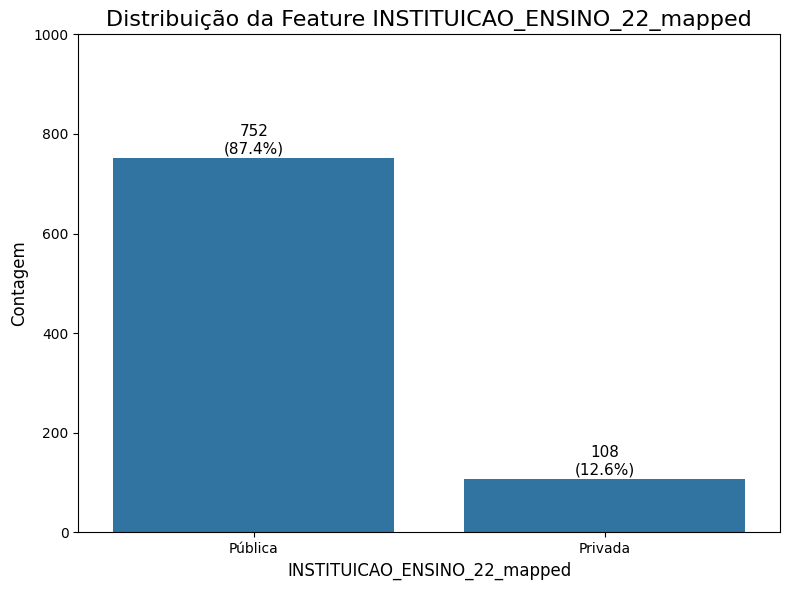

In [42]:
df = df_loaded['INSTITUICAO_ENSINO_22_mapped'].copy()

# Mapear valores numéricos para labels
gender_map = {1: 'Pública', 0: 'Privada'}
df_plot = pd.DataFrame(df).copy()
df_plot['INSTITUICAO_ENSINO_22_mapped_LABEL'] = df_plot['INSTITUICAO_ENSINO_22_mapped'].map(gender_map)

# Definir ordem (opcional - ajuste conforme necessário)
order_labels = ['Pública', 'Privada']

# Visualização da distribuição da feature
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='INSTITUICAO_ENSINO_22_mapped_LABEL', data=df_plot, order=order_labels)

plt.title('Distribuição da Feature INSTITUICAO_ENSINO_22_mapped', fontsize=16)
plt.xlabel('INSTITUICAO_ENSINO_22_mapped', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.ylim(0, 1000)

# Adicionando rótulos
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Feature GÊNERO_22

In [43]:
order_by_label = df_loaded['GÊNERO_22'].value_counts().index
class_counts = df_loaded['GÊNERO_22'].value_counts()

class_percentages = (df_loaded['GÊNERO_22'].value_counts(normalize=True, ) * 100).round(2)
print(class_percentages)

GÊNERO_22
1.0    53.14
0.0    46.86
Name: proportion, dtype: float64


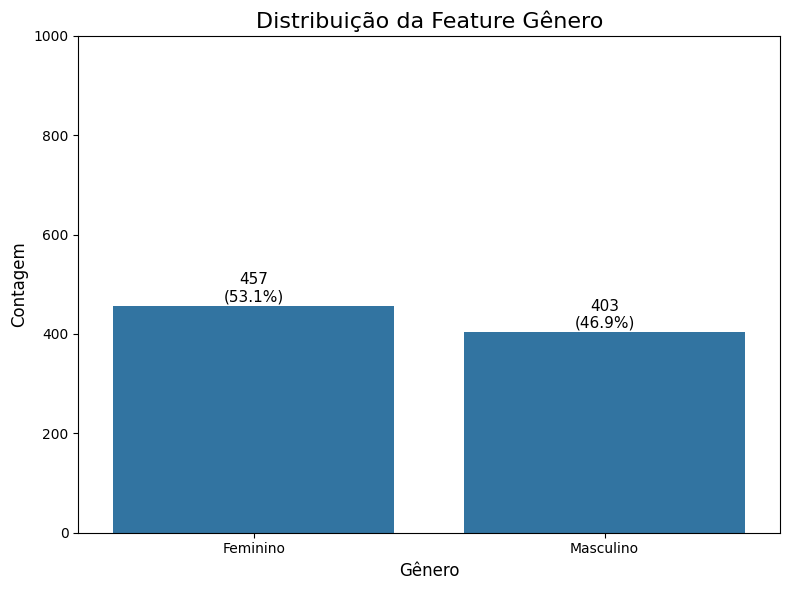

In [44]:
df = df_loaded['GÊNERO_22'].copy()

# Mapear valores numéricos para labels
gender_map = {1: 'Feminino', 0: 'Masculino'}
df_plot = pd.DataFrame(df).copy()
df_plot['GÊNERO_LABEL'] = df_plot['GÊNERO_22'].map(gender_map)

# Definir ordem (opcional - ajuste conforme necessário)
order_labels = ['Feminino', 'Masculino']

# Visualização da distribuição da feature
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='GÊNERO_LABEL', data=df_plot, order=order_labels)

plt.title('Distribuição da Feature Gênero', fontsize=16)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.ylim(0, 1000)

# Adicionando rótulos
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

In [45]:
num_features

['DEFASAGEM_22',
 'IDADE_2022',
 'GÊNERO_22',
 'ANO_INGRESSO_22',
 'VETERANO_22',
 'EM_FASE_22',
 'QTDE_AVAL_2022',
 'IAA_22',
 'IEG_22',
 'IPS_22',
 'IDA_22',
 'IPV_22',
 'IAN_22',
 'INSTITUICAO_ENSINO_22_mapped']

### Análise da variável resposta

In [46]:
order_by_label = df_loaded['EVADIU'].value_counts().index
class_counts = df_loaded['EVADIU'].value_counts()

class_percentages = df_loaded['EVADIU'].value_counts(normalize=True) * 100
print(class_percentages)

EVADIU
0.0    69.767442
1.0    30.232558
Name: proportion, dtype: float64


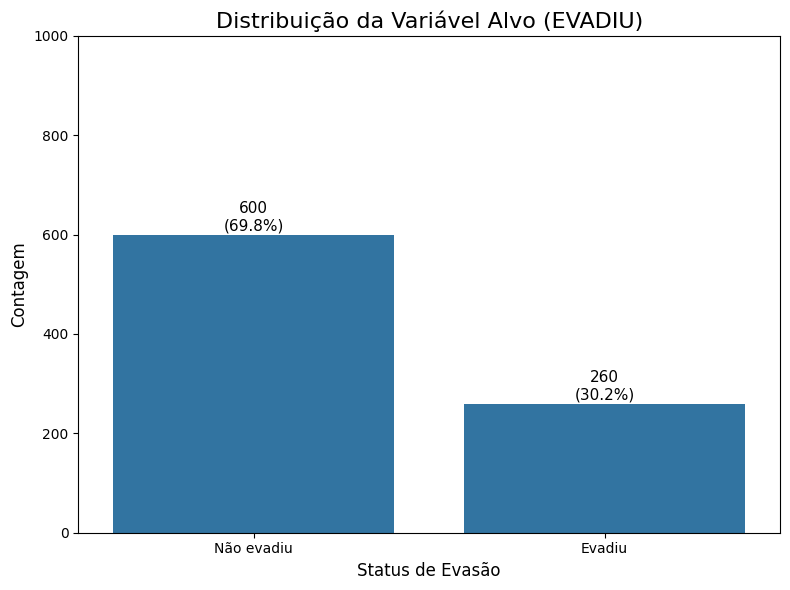

In [47]:
# Mapear os valores para labels primeiro
df_plot = df_loaded.copy()
df_plot['EVADIU_LABEL'] = df_plot['EVADIU'].map({0: 'Não evadiu', 1: 'Evadiu'})

# Visualização da distribuição da variável alvo
plt.figure(figsize=(8, 6))

order_labels = ['Não evadiu', 'Evadiu']
ax = sns.countplot(x='EVADIU_LABEL', data=df_plot, order=order_labels) 

plt.title('Distribuição da Variável Alvo (EVADIU)', fontsize=16)
plt.xlabel('Status de Evasão', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.ylim(0, 1000)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 3,
            f'{int(height)}\n({height/len(df_loaded)*100:.1f}%)',
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

## Análise multivariada

### Matriz de correlação

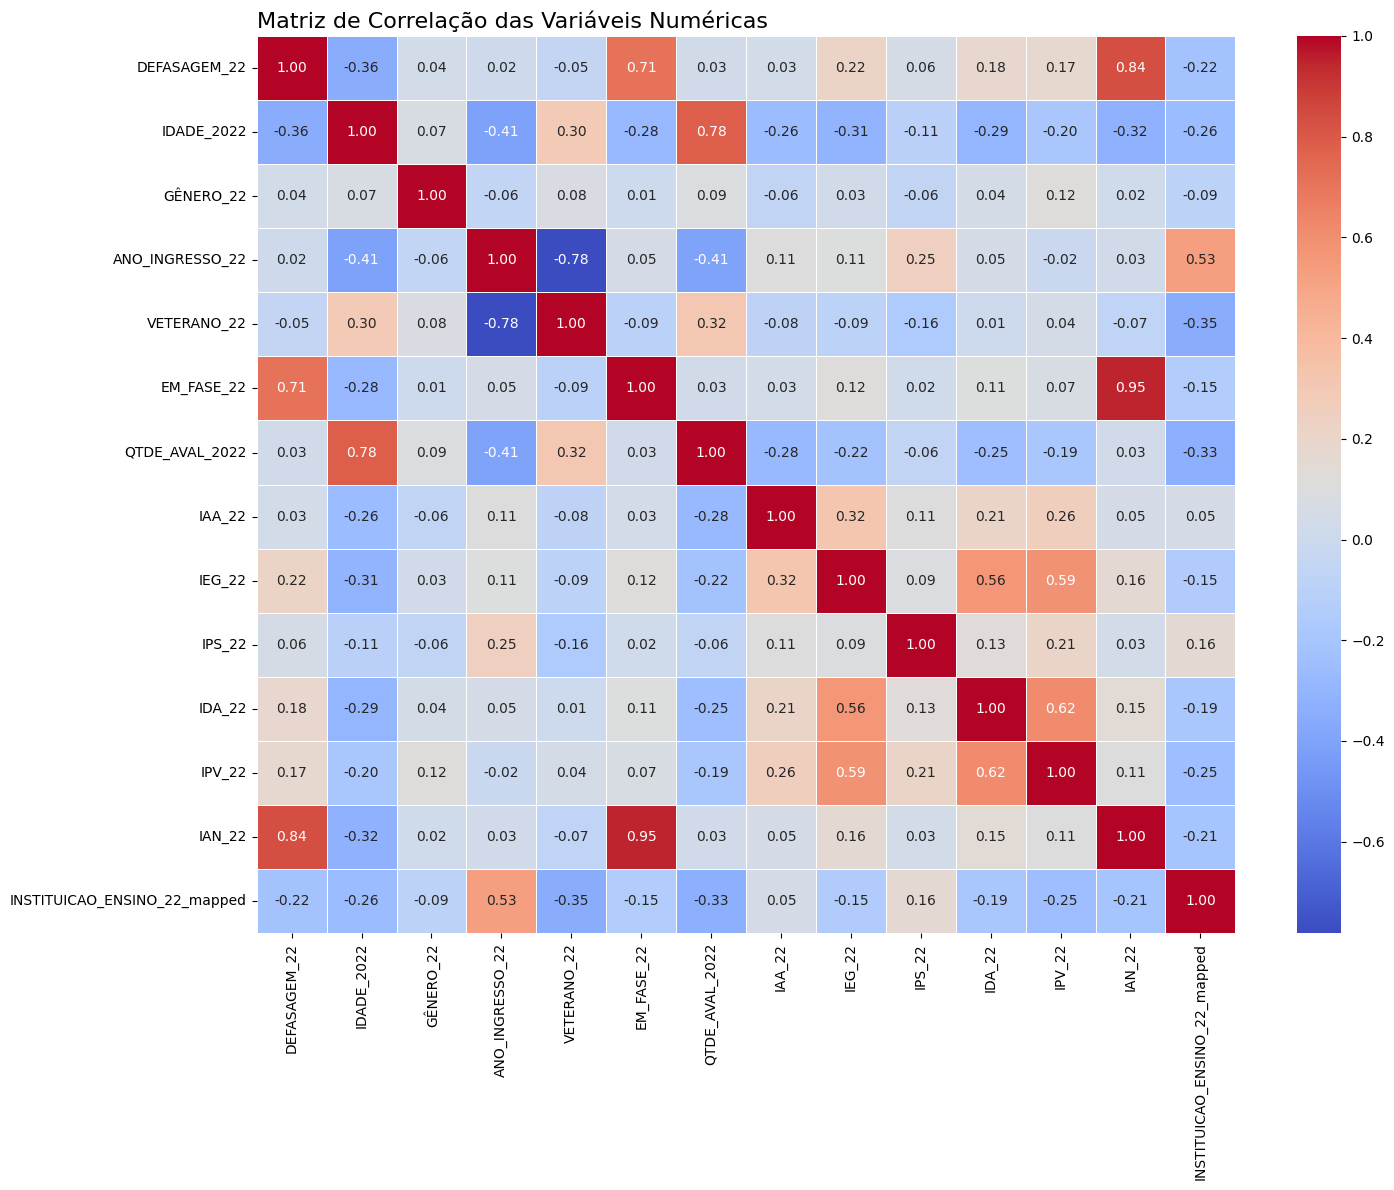

In [48]:
correlation_matrix = df_loaded[num_features].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Exibe os valores de correlação nas células
    cmap='coolwarm',     # Esquema de cores (azul para negativo, vermelho para positivo)
    fmt='.2f',           # Formata os números para duas casas decimais
    linewidths=.5        # Adiciona linhas finas entre as células
)

plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=16, loc='left')

plt.tight_layout()
plt.show()

### Análise das features por classe da variável alvo

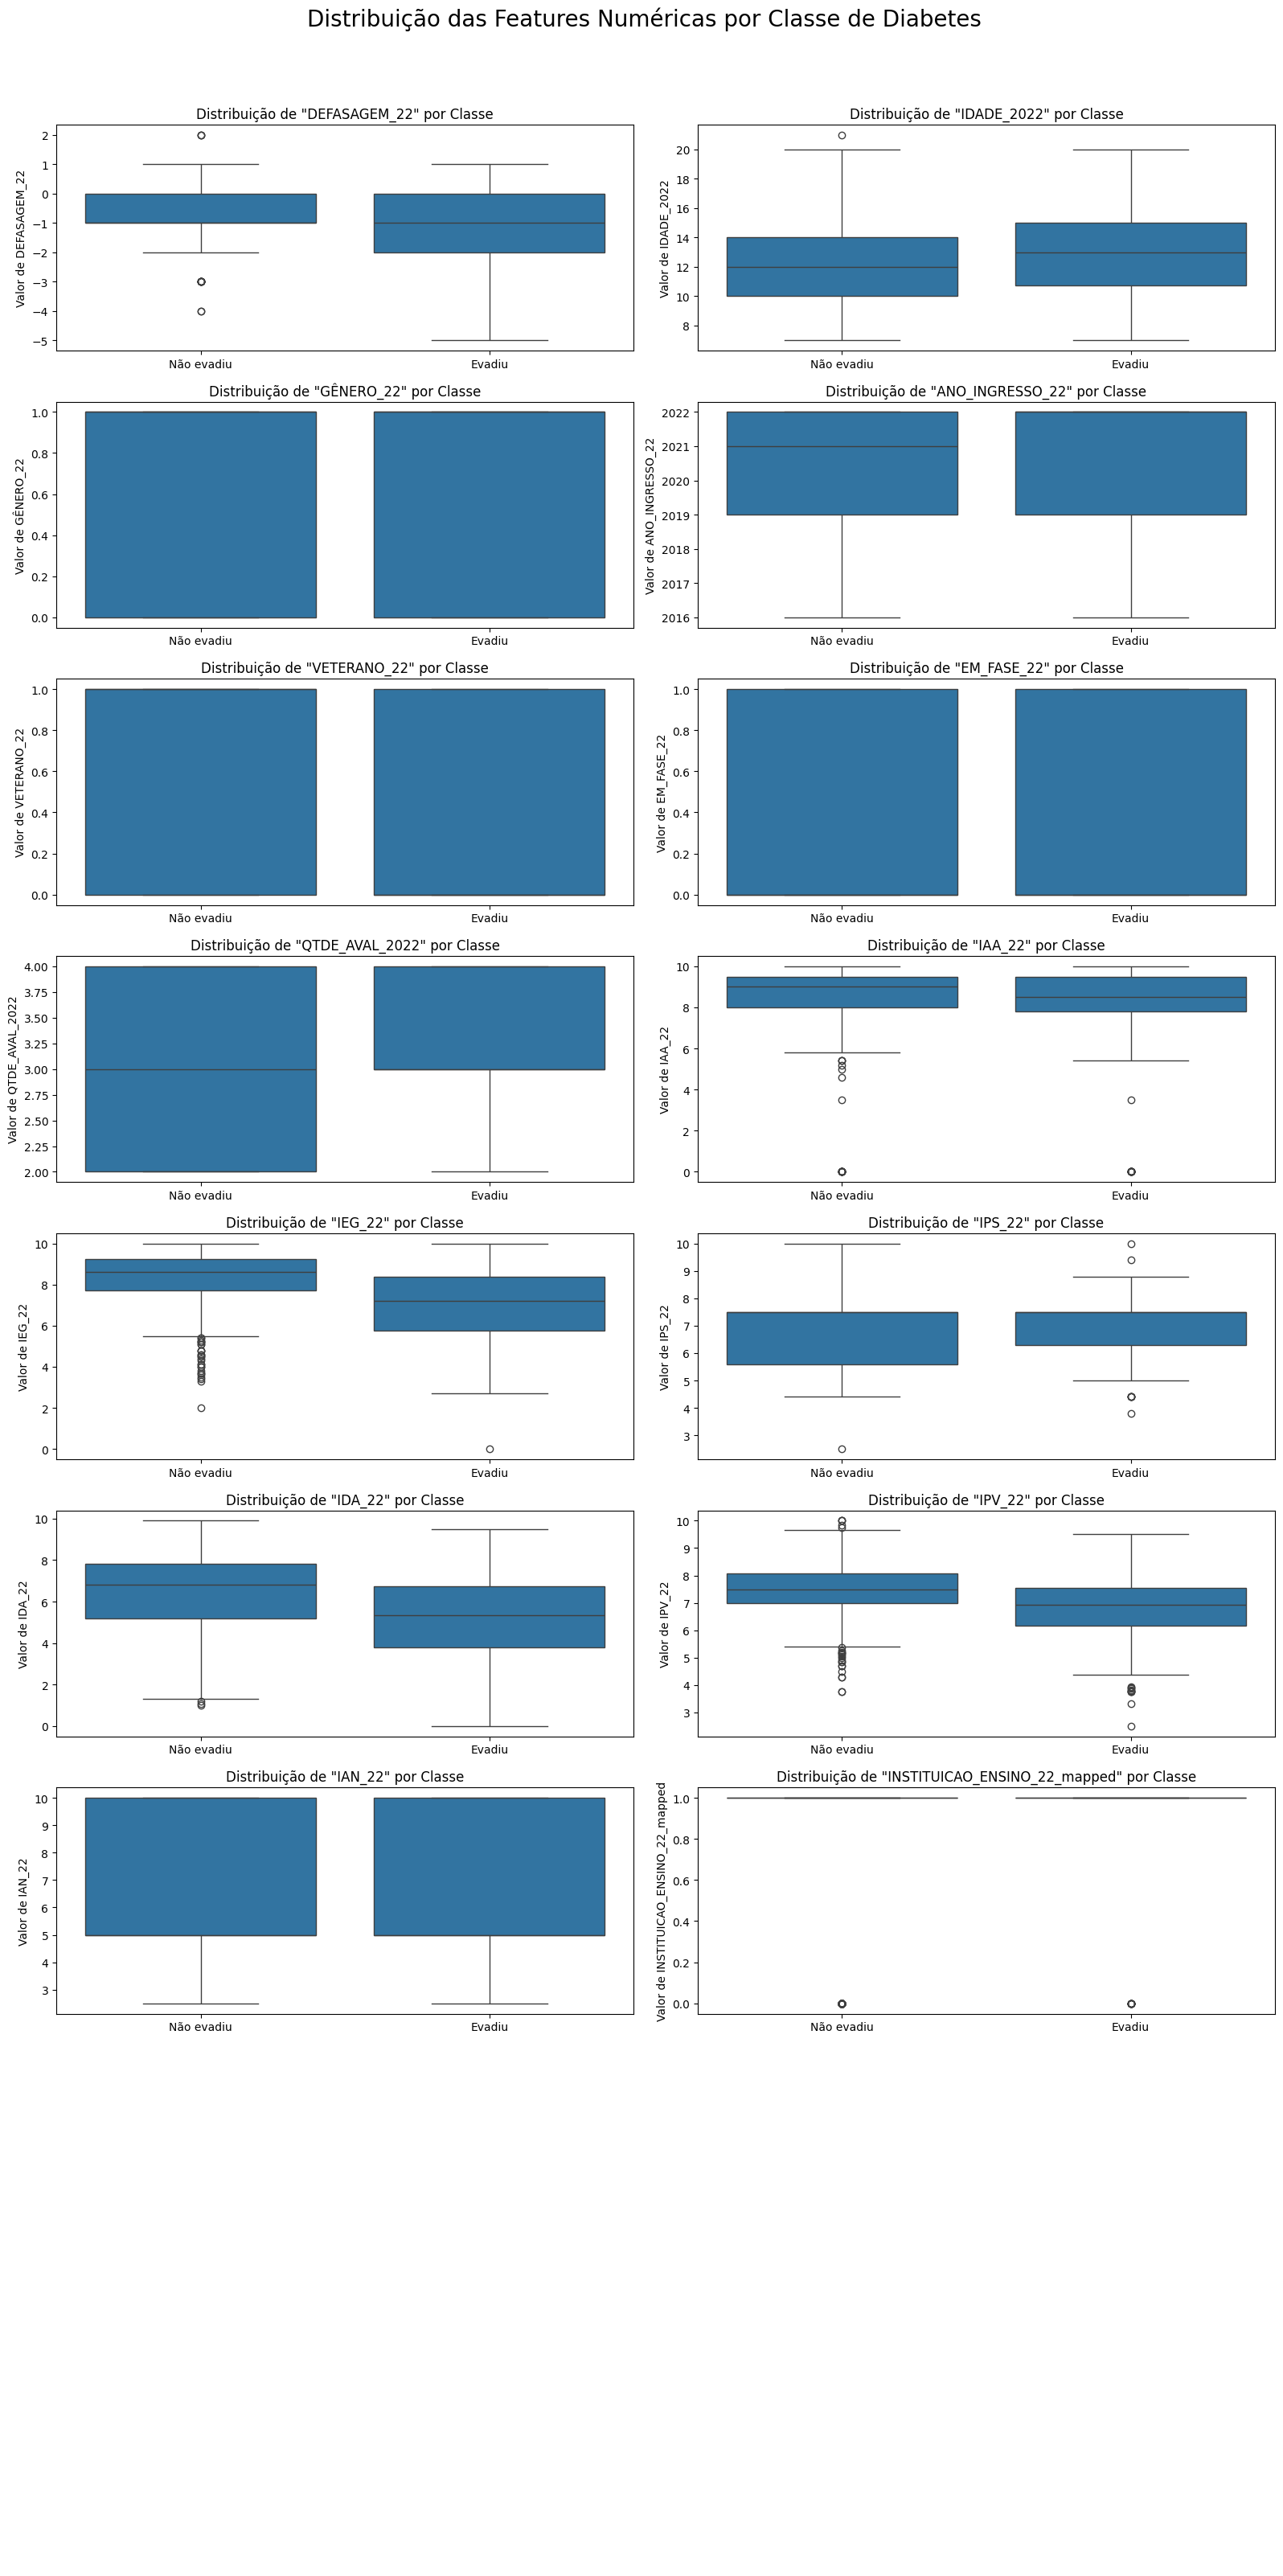

In [49]:
df_loaded['CLASS_LABEL'] = df_loaded['EVADIU'].map({0: 'Não evadiu', 1: 'Evadiu'})

class_order = df_loaded['CLASS_LABEL'].value_counts().index

nrows, ncols = 9, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 32))

# Achatar o array de eixos para facilitar a iteração
axes = axes.flatten()

# Iterando sobre as features e os eixos simultaneamente
for i, col in enumerate(num_features):
    ax = axes[i] # Seleciona o eixo atual
    sns.boxplot(
        x='CLASS_LABEL',
        y=col,
        data=df_loaded,
        order=class_order,
        ax=ax # Especifica em qual eixo o gráfico deve ser desenhado
    )
    ax.set_title(f'Distribuição de "{col}" por Classe', fontsize=12)
    ax.set_xlabel('') # Remove o rótulo do eixo X para limpar a visualização
    ax.set_ylabel(f'Valor de {col}', fontsize=10)
    ax.tick_params(axis='x', rotation=0)

# Ocultando os eixos extras que não foram utilizados
for i in range(len(num_features), len(axes)):
    axes[i].axis('off')

# Adicionando um título geral para toda a figura
fig.suptitle('Distribuição das Features Numéricas por Classe de Diabetes', fontsize=20, y=1.0)

# Ajustando o layout para evitar sobreposição
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### GÊNERO_22 x EVADIU

In [50]:
df_loaded['Gender_label'] = df_loaded['GÊNERO_22'].map({1: 'Feminino', 0: 'Masculino'})

# Criando a tabela de contingência
contingency_table = pd.crosstab(df_loaded['Gender_label'], df_loaded['CLASS_LABEL'])

print("Tabela de Contingência: Gender vs. Class\n")
print(contingency_table)

Tabela de Contingência: Gender vs. Class

CLASS_LABEL   Evadiu  Não evadiu
Gender_label                    
Feminino         144         313
Masculino        116         287



Tabela de Contingência (Percentual por Gênero):

CLASS_LABEL      Evadiu  Não evadiu
Gender_label                       
Feminino      31.509847   68.490153
Masculino     28.784119   71.215881


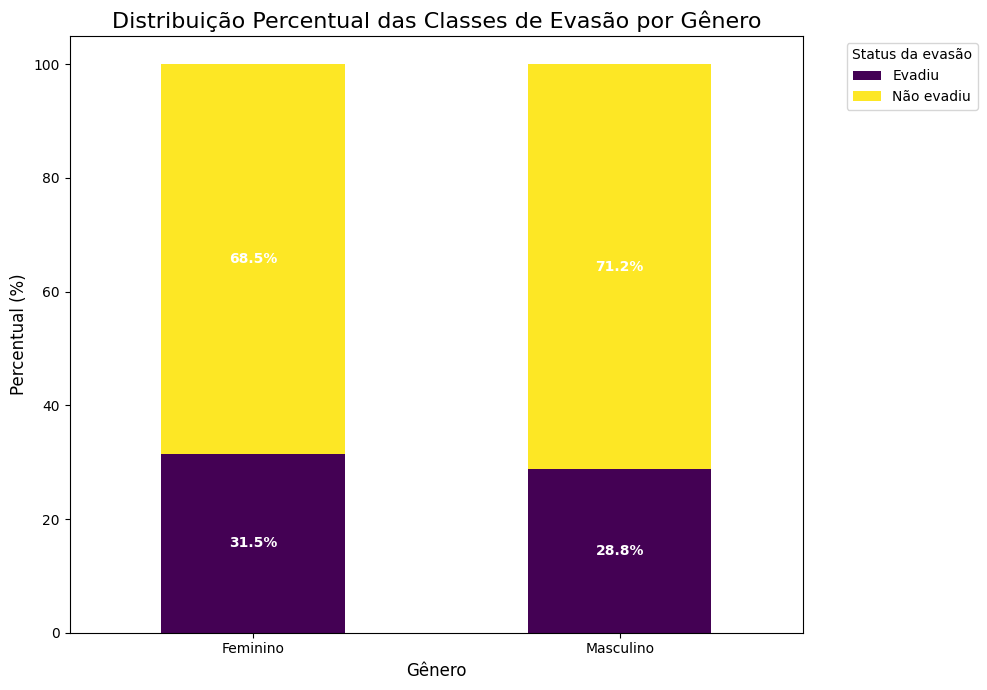

In [51]:
contingency_table_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print("\nTabela de Contingência (Percentual por Gênero):\n")
print(contingency_table_pct)

# Criando o gráfico de barras empilhadas 100%
ax = contingency_table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    colormap='viridis'
)

plt.title('Distribuição Percentual das Classes de Evasão por Gênero', fontsize=16)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status da evasão', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de porcentagem no gráfico
for c in ax.containers:
    # A formatação pode ser ajustada para melhor visualização
    labels = [f'{w:.1f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

In [52]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Teste Qui-quadrado de Independência ---\n")
print(f"Estatística Qui-quadrado: {chi2:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Graus de Liberdade (dof): {dof}")

alpha = 0.05
if p_value <= alpha:
    print(f"\nConclusão (alpha={alpha}): Rejeitamos a hipótese nula.")
    print("Há uma associação estatisticamente significativa entre Gênero e Classe de Evasão.")
else:
    print(f"\nConclusão (alpha={alpha}): Falhamos em rejeitar a hipótese nula.")
    print("Não há evidência de uma associação estatisticamente significativa entre Gênero e Classe de Evasão.")


--- Teste Qui-quadrado de Independência ---

Estatística Qui-quadrado: 0.6306
P-valor: 0.4271
Graus de Liberdade (dof): 1

Conclusão (alpha=0.05): Falhamos em rejeitar a hipótese nula.
Não há evidência de uma associação estatisticamente significativa entre Gênero e Classe de Evasão.


### VETERANO_22 x EVADIU

In [53]:
df_loaded['Veterano_label'] = df_loaded['VETERANO_22'].map({1: 'Veterano', 0: 'Novato'})

# Criando a tabela de contingência
contingency_table = pd.crosstab(df_loaded['Veterano_label'], df_loaded['CLASS_LABEL'])

print("Tabela de Contingência: Veterano vs. Class\n")
print(contingency_table)

Tabela de Contingência: Veterano vs. Class

CLASS_LABEL     Evadiu  Não evadiu
Veterano_label                    
Novato             133         266
Veterano           127         334



Tabela de Contingência (Percentual por Veterano):

CLASS_LABEL        Evadiu  Não evadiu
Veterano_label                       
Novato          33.333333   66.666667
Veterano        27.548807   72.451193


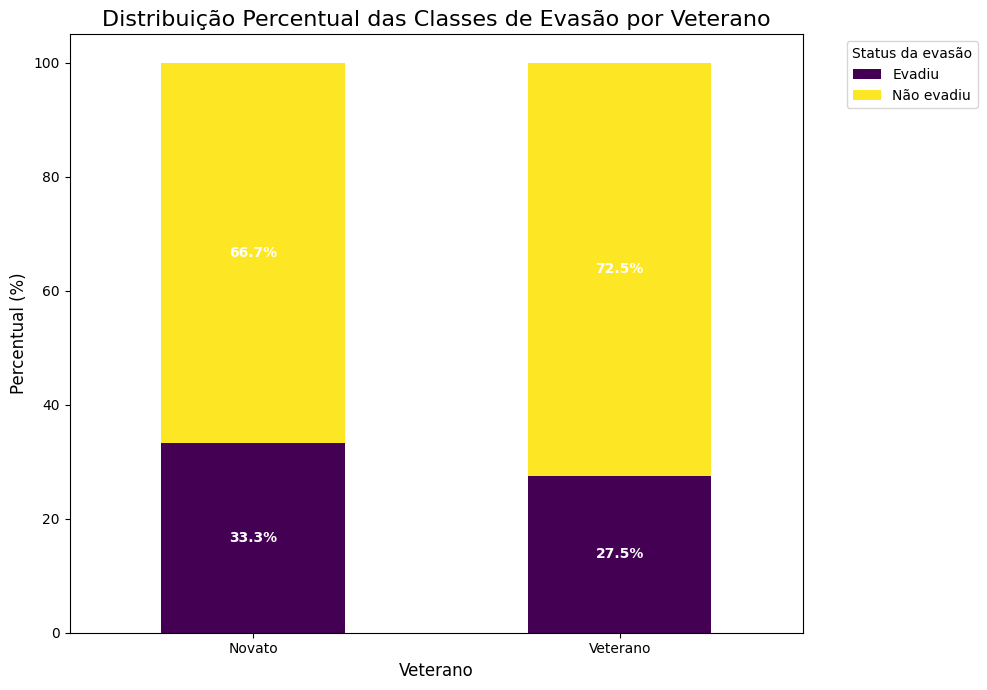

In [54]:
contingency_table_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print("\nTabela de Contingência (Percentual por Veterano):\n")
print(contingency_table_pct)

# Criando o gráfico de barras empilhadas 100%
ax = contingency_table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    colormap='viridis'
)

plt.title('Distribuição Percentual das Classes de Evasão por Veterano', fontsize=16)
plt.xlabel('Veterano', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status da evasão', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de porcentagem no gráfico
for c in ax.containers:
    # A formatação pode ser ajustada para melhor visualização
    labels = [f'{w:.1f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

In [55]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Teste Qui-quadrado de Independência ---\n")
print(f"Estatística Qui-quadrado: {chi2:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Graus de Liberdade (dof): {dof}")

alpha = 0.05
if p_value <= alpha:
    print(f"\nConclusão (alpha={alpha}): Rejeitamos a hipótese nula.")
    print("Há uma associação estatisticamente significativa entre Veterano e Classe de Evasão.")
else:
    print(f"\nConclusão (alpha={alpha}): Falhamos em rejeitar a hipótese nula.")
    print("Não há evidência de uma associação estatisticamente significativa entre Veterano e Classe de Evasão.")


--- Teste Qui-quadrado de Independência ---

Estatística Qui-quadrado: 3.1243
P-valor: 0.0771
Graus de Liberdade (dof): 1

Conclusão (alpha=0.05): Falhamos em rejeitar a hipótese nula.
Não há evidência de uma associação estatisticamente significativa entre Veterano e Classe de Evasão.


### EM_FASE_22 x EVADIU

In [56]:
df_loaded['Defasagem_label'] = df_loaded['EM_FASE_22'].map({1: 'Em fase', 0: 'Defasado'})

# Criando a tabela de contingência
contingency_table = pd.crosstab(df_loaded['Defasagem_label'], df_loaded['CLASS_LABEL'])

print("Tabela de Contingência: Defasagem vs. Class\n")
print(contingency_table)

Tabela de Contingência: Defasagem vs. Class

CLASS_LABEL      Evadiu  Não evadiu
Defasagem_label                    
Defasado            191         422
Em fase              69         178



Tabela de Contingência (Percentual por Defasagem):

CLASS_LABEL         Evadiu  Não evadiu
Defasagem_label                       
Defasado         31.158238   68.841762
Em fase          27.935223   72.064777


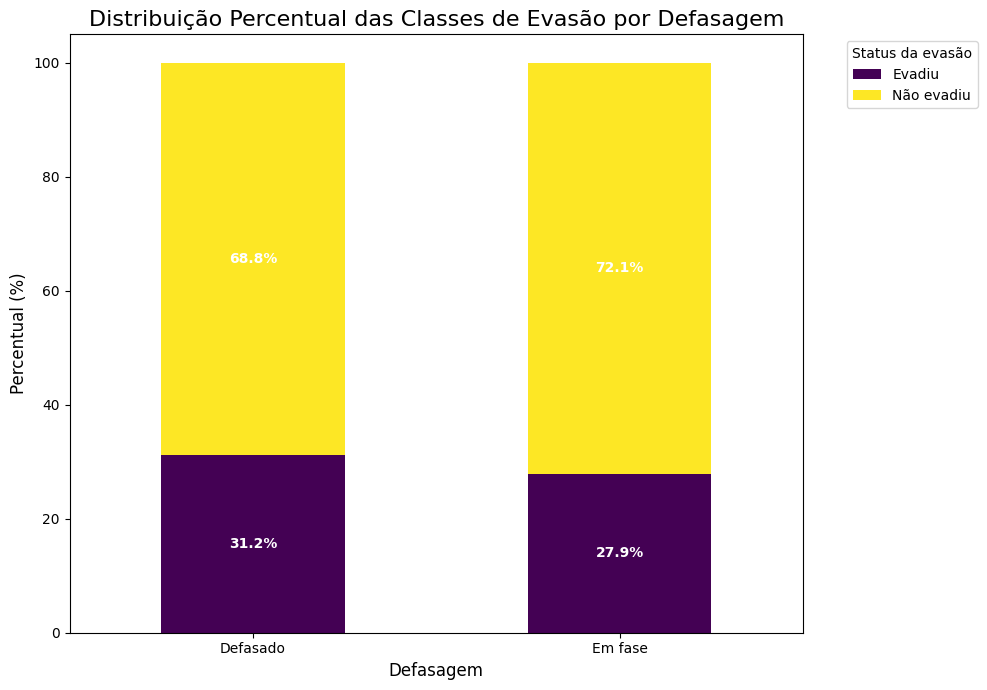

In [57]:
contingency_table_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print("\nTabela de Contingência (Percentual por Defasagem):\n")
print(contingency_table_pct)

# Criando o gráfico de barras empilhadas 100%
ax = contingency_table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    colormap='viridis'
)

plt.title('Distribuição Percentual das Classes de Evasão por Defasagem', fontsize=16)
plt.xlabel('Defasagem', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status da evasão', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de porcentagem no gráfico
for c in ax.containers:
    # A formatação pode ser ajustada para melhor visualização
    labels = [f'{w:.1f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

In [58]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Teste Qui-quadrado de Independência ---\n")
print(f"Estatística Qui-quadrado: {chi2:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Graus de Liberdade (dof): {dof}")

alpha = 0.05
if p_value <= alpha:
    print(f"\nConclusão (alpha={alpha}): Rejeitamos a hipótese nula.")
    print("Há uma associação estatisticamente significativa entre Defasagem e Classe de Evasão.")
else:
    print(f"\nConclusão (alpha={alpha}): Falhamos em rejeitar a hipótese nula.")
    print("Não há evidência de uma associação estatisticamente significativa entre Defasagem e Classe de Evasão.")


--- Teste Qui-quadrado de Independência ---

Estatística Qui-quadrado: 0.7210
P-valor: 0.3958
Graus de Liberdade (dof): 1

Conclusão (alpha=0.05): Falhamos em rejeitar a hipótese nula.
Não há evidência de uma associação estatisticamente significativa entre Defasagem e Classe de Evasão.


### INSTITUICAO_ENSINO_22 x EVADIU

In [59]:
df_loaded['Instituicao_label'] = df_loaded['INSTITUICAO_ENSINO_22_mapped'].map({1: 'Pública', 0: 'Privada'})

# Criando a tabela de contingência
contingency_table = pd.crosstab(df_loaded['Instituicao_label'], df_loaded['CLASS_LABEL'])

print("Tabela de Contingência: Instituição vs. Class\n")
print(contingency_table)

Tabela de Contingência: Instituição vs. Class

CLASS_LABEL        Evadiu  Não evadiu
Instituicao_label                    
Privada                13          95
Pública               247         505



Tabela de Contingência (Percentual por Instituição):

CLASS_LABEL           Evadiu  Não evadiu
Instituicao_label                       
Privada            12.037037   87.962963
Pública            32.845745   67.154255


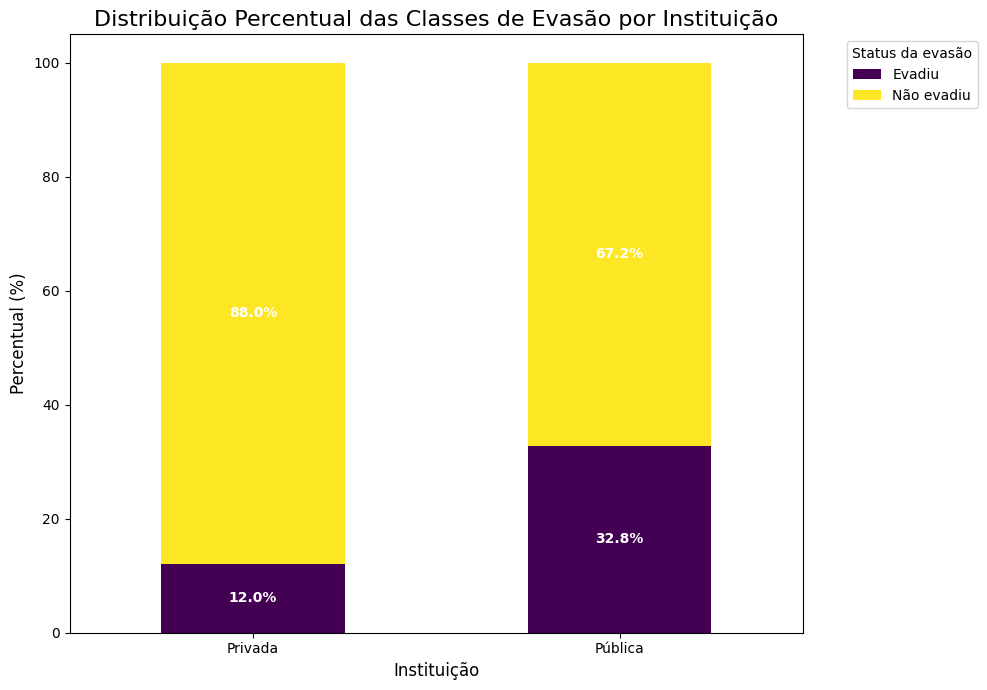

In [60]:
contingency_table_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print("\nTabela de Contingência (Percentual por Instituição):\n")
print(contingency_table_pct)

# Criando o gráfico de barras empilhadas 100%
ax = contingency_table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    colormap='viridis'
)

plt.title('Distribuição Percentual das Classes de Evasão por Instituição', fontsize=16)
plt.xlabel('Instituição', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status da evasão', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de porcentagem no gráfico
for c in ax.containers:
    # A formatação pode ser ajustada para melhor visualização
    labels = [f'{w:.1f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

In [61]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Teste Qui-quadrado de Independência ---\n")
print(f"Estatística Qui-quadrado: {chi2:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Graus de Liberdade (dof): {dof}")

alpha = 0.05
if p_value <= alpha:
    print(f"\nConclusão (alpha={alpha}): Rejeitamos a hipótese nula.")
    print("Há uma associação estatisticamente significativa entre Instituição e Classe de Evasão.")
else:
    print(f"\nConclusão (alpha={alpha}): Falhamos em rejeitar a hipótese nula.")
    print("Não há evidência de uma associação estatisticamente significativa entre Instituição e Classe de Evasão.")


--- Teste Qui-quadrado de Independência ---

Estatística Qui-quadrado: 18.4128
P-valor: 0.0000
Graus de Liberdade (dof): 1

Conclusão (alpha=0.05): Rejeitamos a hipótese nula.
Há uma associação estatisticamente significativa entre Instituição e Classe de Evasão.


### PairPlot

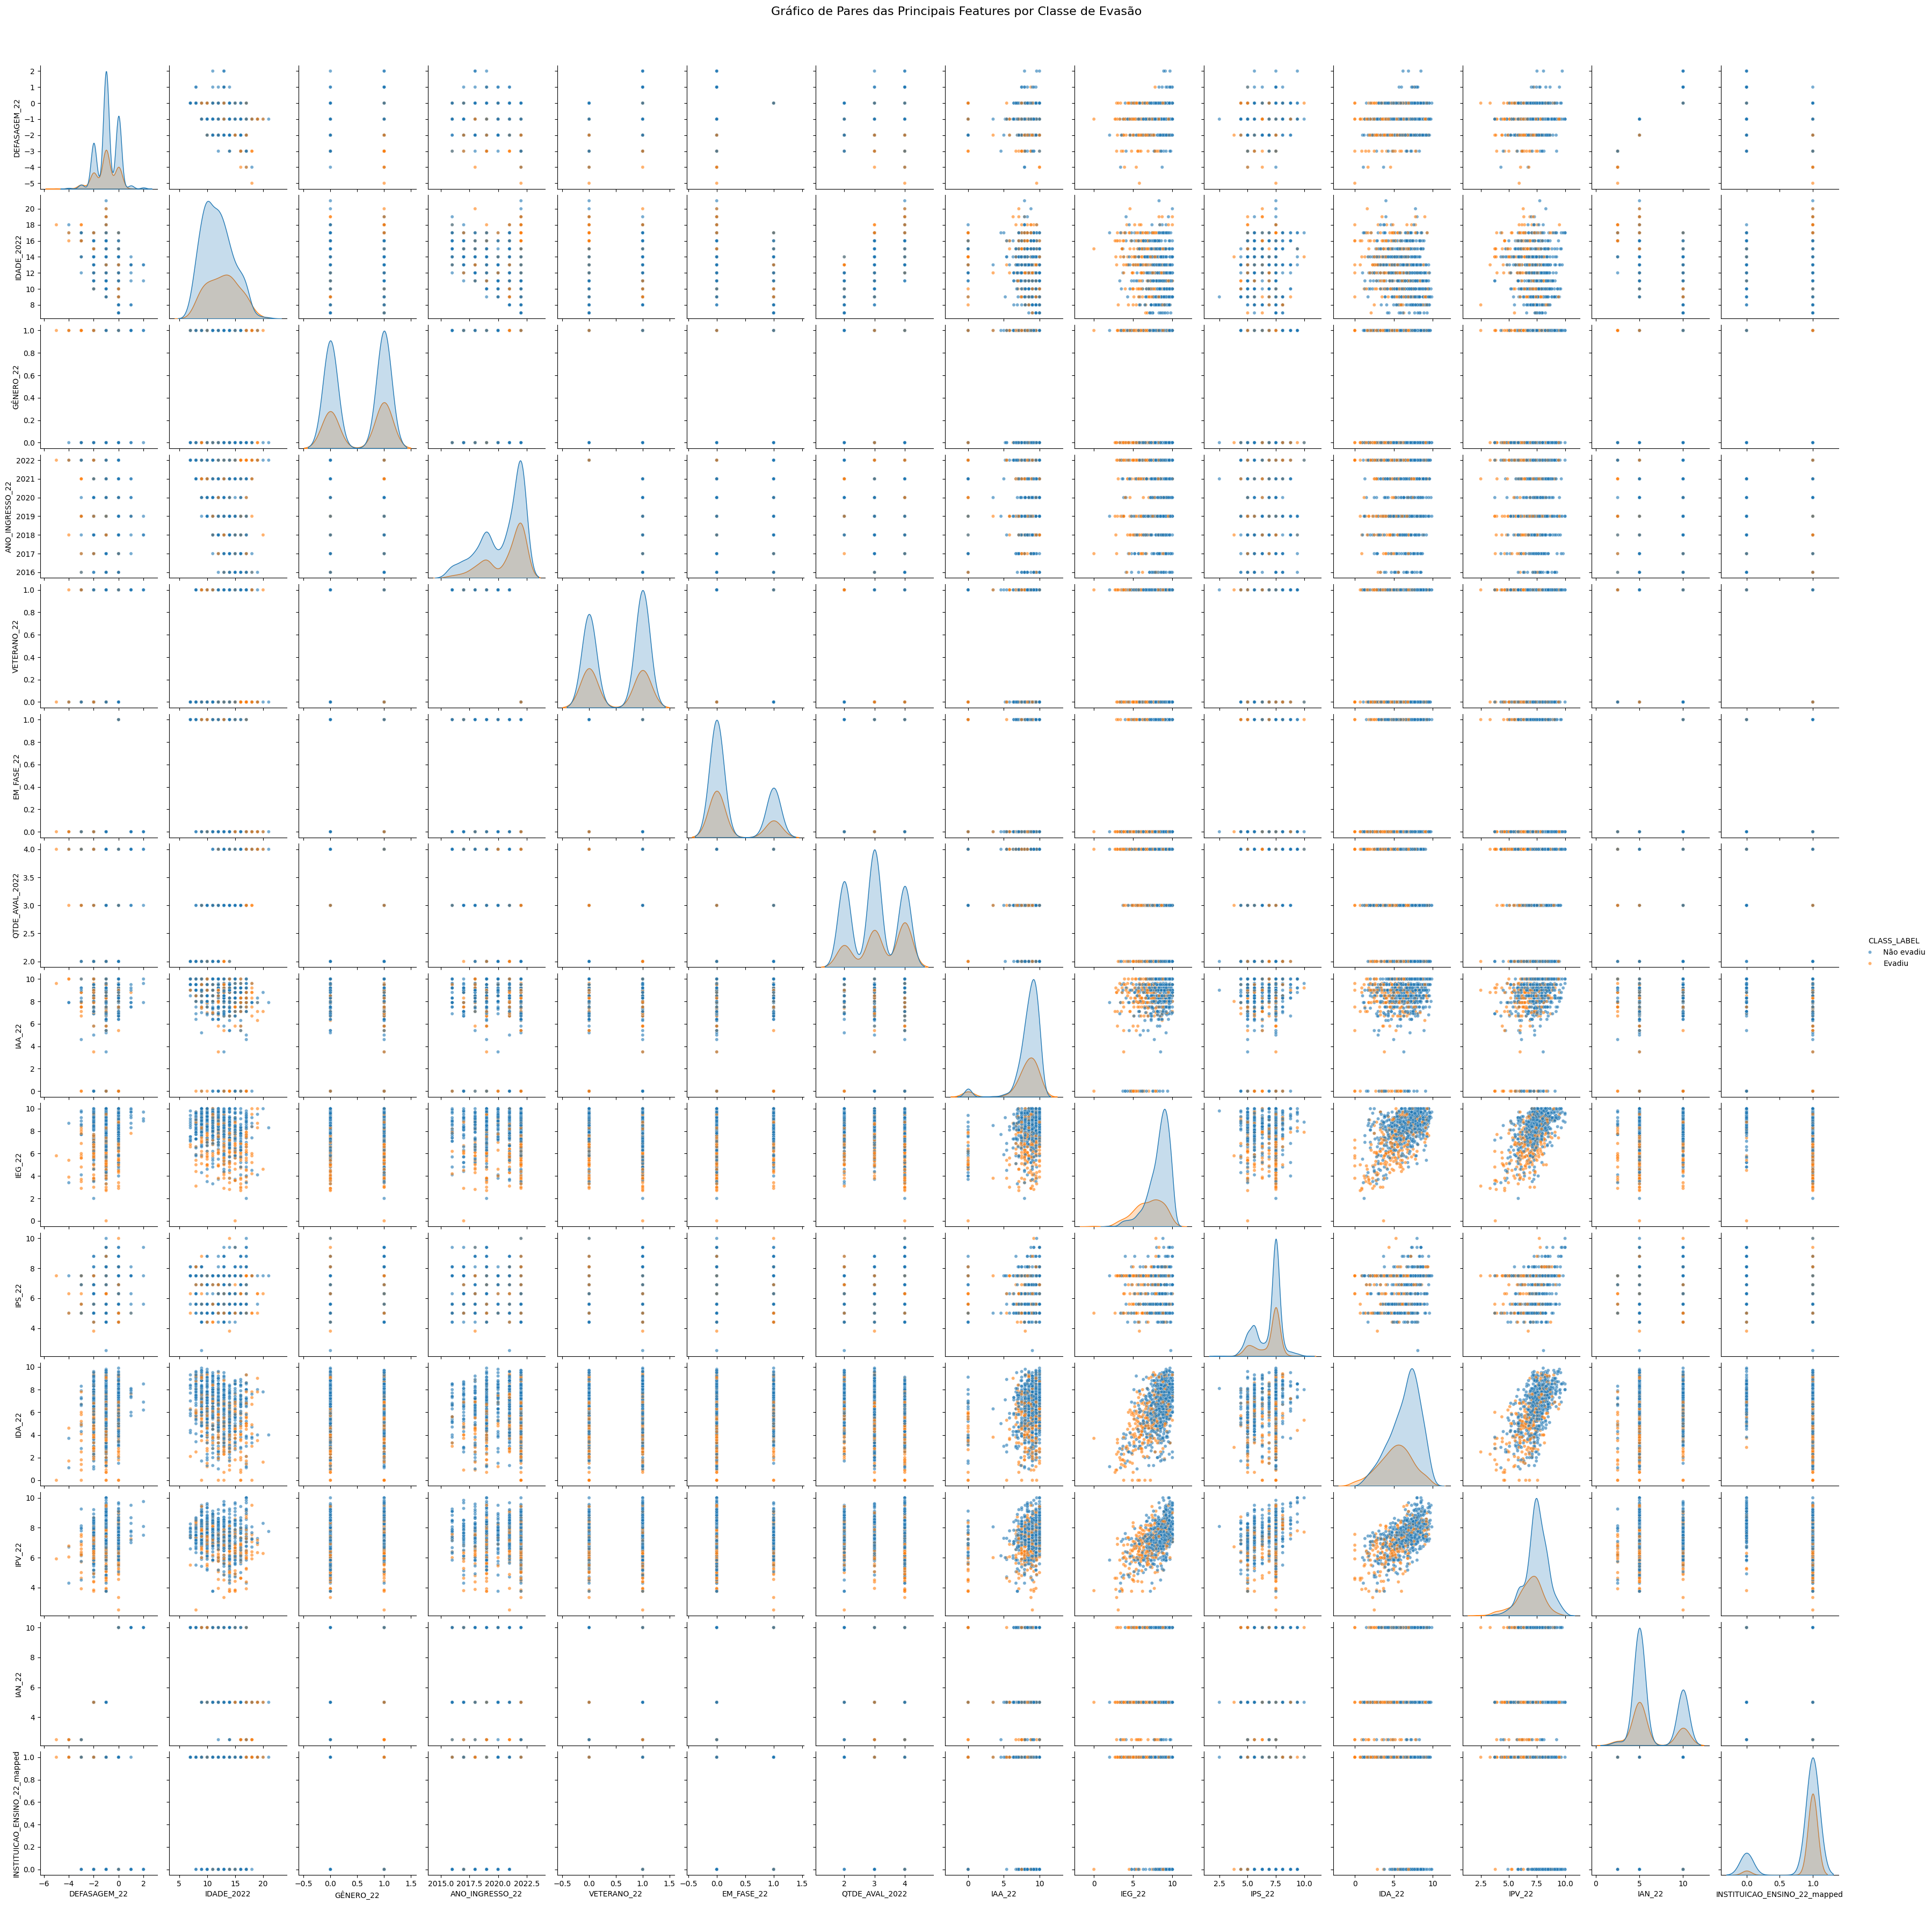

In [62]:
features_for_pairplot = num_features

# Criando o pair plot
# diag_kind='kde' mostra a densidade da distribuição na diagonal
g = sns.pairplot(
    data=df_loaded,
    vars=features_for_pairplot,
    hue='CLASS_LABEL',
    #palette='viridis', # Esquema de cores
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 20} # Ajusta a transparência e o tamanho dos pontos
)

# Adicionando um título geral
g.fig.suptitle('Gráfico de Pares das Principais Features por Classe de Evasão', y=1.02, fontsize=16)

plt.show()

# Pré-processamento

## Transformação logarítmica

In [63]:
skewness = df_loaded[num_features].drop(columns=['INSTITUICAO_ENSINO_22_mapped']).skew()

# Selecionando colunas com skewness >= 1 ou <= -1
high_skew_columns = skewness[(skewness >= 1) | (skewness <= -1)]

# Nomes das colunas com alta skewness
skew_column_names = high_skew_columns.index.tolist()

df_log = aplicar_transformacao_log(df_loaded, skew_column_names)

display(df_log[[col for col in df_log.columns.tolist() if col.endswith("_log")]].head())

,IAA_22_log,IEG_22_log
0,2.230014,1.629241
1,2.230014,1.824549
2,2.282382,2.174752
3,2.186051,2.230014
4,2.041220,2.163323


### Visualização da transformação

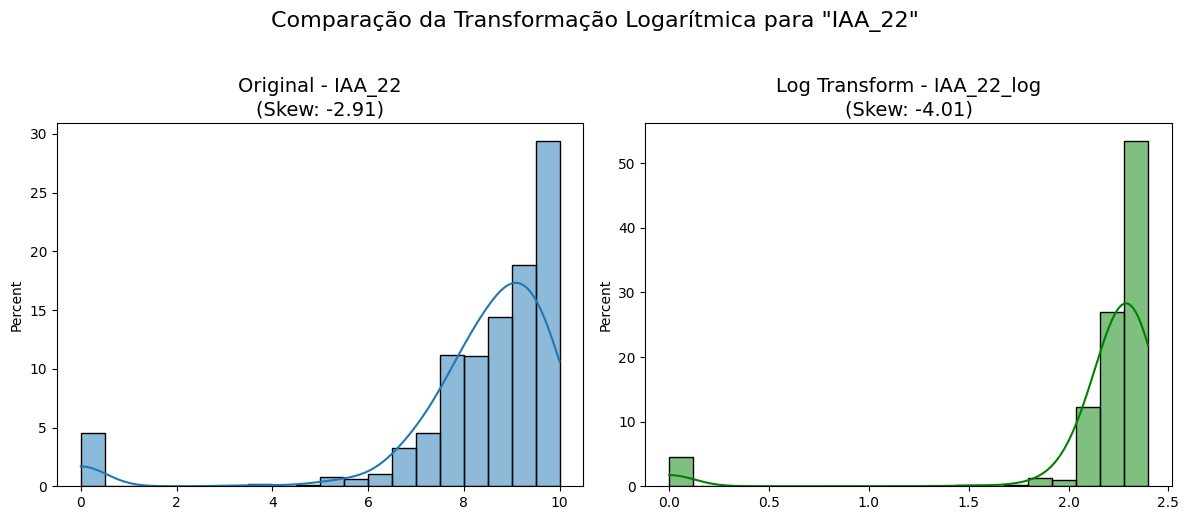

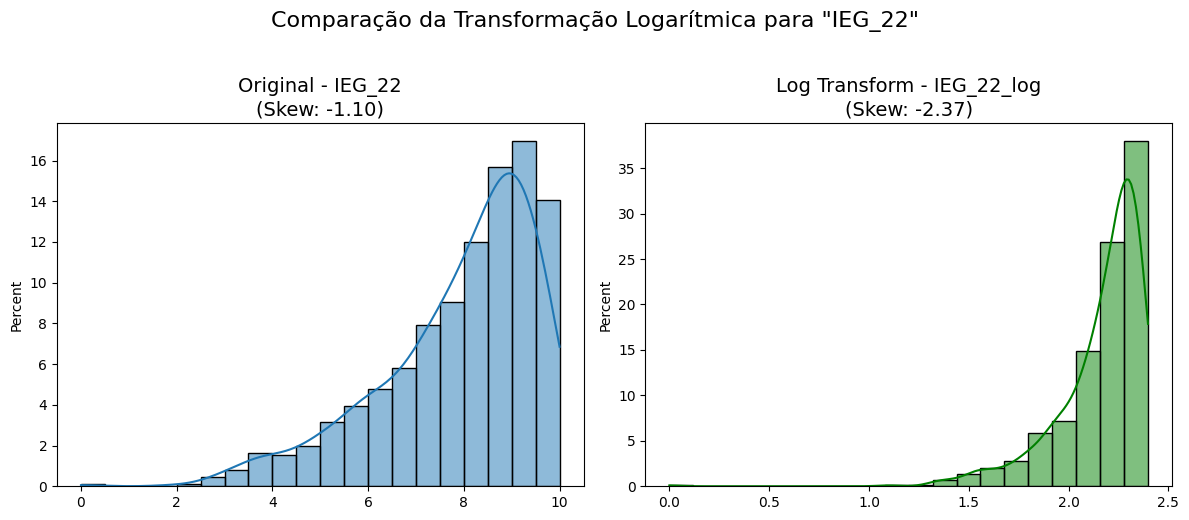

In [64]:
for col in skew_column_names:
    # Criando a figura e os eixos para o subplot (1 linha, 2 colunas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Gráfico 1: Distribuição Original ---
    skew_original = df_log[col].skew()
    sns.histplot(df_log[col], kde=True, ax=axes[0], bins=20, stat='percent')
    axes[0].set_title(f'Original - {col}\n(Skew: {skew_original:.2f})', fontsize=14)
    axes[0].set_xlabel('')

    # --- Gráfico 2: Distribuição com Transformação Logarítmica ---
    col_log = col + '_log'
    skew_transformado = df_log[col_log].skew()
    sns.histplot(df_log[col_log], kde=True, ax=axes[1], bins=20, stat='percent', color='green')
    axes[1].set_title(f'Log Transform - {col_log}\n(Skew: {skew_transformado:.2f})', fontsize=14)
    axes[1].set_xlabel('')

    # Título geral
    fig.suptitle(f'Comparação da Transformação Logarítmica para "{col}"', fontsize=16, y=1.03)

    plt.tight_layout()
    plt.show()

In [65]:
df_loaded[num_features]

,DEFASAGEM_22,IDADE_2022,GÊNERO_22,ANO_INGRESSO_22,VETERANO_22,EM_FASE_22,QTDE_AVAL_2022,IAA_22,IEG_22,IPS_22,IDA_22,IPV_22,IAN_22,INSTITUICAO_ENSINO_22_mapped
0,-1.0,19.0,1.0,2016.0,1.0,0.0,4.0,8.3,4.1,5.6,4.0,7.278,5.0,1
1,-1.0,18.0,1.0,2021.0,1.0,0.0,4.0,8.3,5.2,5.0,4.1,7.056,5.0,1
2,1.0,13.0,1.0,2019.0,1.0,0.0,4.0,8.8,7.8,5.0,7.6,7.250,10.0,0
3,-1.0,15.0,1.0,2021.0,1.0,0.0,4.0,7.9,8.3,7.5,7.6,6.833,5.0,1
4,0.0,14.0,0.0,2019.0,1.0,1.0,4.0,6.7,7.7,6.9,5.7,6.000,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
855,-2.0,17.0,1.0,2022.0,0.0,0.0,4.0,8.3,6.6,7.5,4.8,6.292,5.0,1
856,-1.0,16.0,0.0,2021.0,1.0,0.0,4.0,9.2,7.8,6.9,6.7,8.500,5.0,1
857,0.0,15.0,1.0,2017.0,1.0,1.0,4.0,7.5,8.8,5.0,6.9,6.292,10.0,0
858,0.0,15.0,1.0,2017.0,1.0,1.0,4.0,8.8,10.0,9.4,8.5,9.667,10.0,0


## Separação dos dados para modelagem

### selecionando as colunas alvo

In [66]:
df_loaded[num_features].head()

,DEFASAGEM_22,IDADE_2022,GÊNERO_22,ANO_INGRESSO_22,VETERANO_22,EM_FASE_22,QTDE_AVAL_2022,IAA_22,IEG_22,IPS_22,IDA_22,IPV_22,IAN_22,INSTITUICAO_ENSINO_22_mapped
0,-1.0,19.0,1.0,2016.0,1.0,0.0,4.0,8.3,4.1,5.6,4.0,7.278,5.0,1
1,-1.0,18.0,1.0,2021.0,1.0,0.0,4.0,8.3,5.2,5.0,4.1,7.056,5.0,1
2,1.0,13.0,1.0,2019.0,1.0,0.0,4.0,8.8,7.8,5.0,7.6,7.250,10.0,0
3,-1.0,15.0,1.0,2021.0,1.0,0.0,4.0,7.9,8.3,7.5,7.6,6.833,5.0,1
4,0.0,14.0,0.0,2019.0,1.0,1.0,4.0,6.7,7.7,6.9,5.7,6.000,10.0,1


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    df_loaded[num_features],
    df_loaded['EVADIU'],
    test_size=0.2,
    random_state=42,
    stratify=df_loaded['EVADIU']
)

# Modelagem - Random Forest

## Parâmetros e modelo

In [68]:
N_SPLITS = 5 # Número de folds para a validação cruzada
RANDOM_STATE = 42

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [69]:
rf_params = {
    'n_estimators': 100,
    'criterion': 'log_loss',
    'max_depth': 5,
    'max_features': X_train.shape[1],
    'class_weight': 'balanced',
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

model_rf = RandomForestClassifier(**rf_params)

## Validação cruzada

In [70]:
results_rf = perform_cross_validation(
    X_train=X_train,
    y_train=y_train,
    skf=skf,
    model=model_rf,
)


Processando Fold 1/5

Train      - Acc: 0.7927 | F1: 0.6902 | ROC-AUC: 0.8952
Validation - Acc: 0.7174 | F1: 0.5618 | ROC-AUC: 0.7264

Processando Fold 2/5

Train      - Acc: 0.8236 | F1: 0.7236 | ROC-AUC: 0.9050
Validation - Acc: 0.7101 | F1: 0.5122 | ROC-AUC: 0.7143

Processando Fold 3/5

Train      - Acc: 0.8200 | F1: 0.7195 | ROC-AUC: 0.9009
Validation - Acc: 0.6884 | F1: 0.5275 | ROC-AUC: 0.7101

Processando Fold 4/5

Train      - Acc: 0.8004 | F1: 0.6910 | ROC-AUC: 0.8955
Validation - Acc: 0.7372 | F1: 0.6000 | ROC-AUC: 0.7289

Processando Fold 5/5

Train      - Acc: 0.7895 | F1: 0.6882 | ROC-AUC: 0.8878
Validation - Acc: 0.7007 | F1: 0.5495 | ROC-AUC: 0.7409

✅ Validação Cruzada concluída!


In [71]:
print("\n--- Resultados Finais da Validação Cruzada (Média ± Desvio Padrão) ---")

for metric_name in results_rf['validation']:
    mean_train = np.mean(results_rf['train'][metric_name])
    std_train = np.std(results_rf['train'][metric_name])
    mean_val = np.mean(results_rf['validation'][metric_name])
    std_val = np.std(results_rf['validation'][metric_name])

    print(f"\nMétrica: {metric_name.replace('_', ' ').title()}")
    print(f"  - Treino     : {mean_train:.4f} ± {std_train:.4f}")
    print(f"  - Validação  : {mean_val:.4f} ± {std_val:.4f}")


--- Resultados Finais da Validação Cruzada (Média ± Desvio Padrão) ---

Métrica: Accuracy
  - Treino     : 0.8052 ± 0.0140
  - Validação  : 0.7108 ± 0.0164

Métrica: F1 Score
  - Treino     : 0.7025 ± 0.0157
  - Validação  : 0.5502 ± 0.0303

Métrica: Recall
  - Treino     : 0.7596 ± 0.0116
  - Validação  : 0.5870 ± 0.0520

Métrica: Precision
  - Treino     : 0.6539 ± 0.0254
  - Validação  : 0.5195 ± 0.0221

Métrica: Log Loss
  - Treino     : 0.4421 ± 0.0051
  - Validação  : 0.5807 ± 0.0203

Métrica: Roc Auc
  - Treino     : 0.8969 ± 0.0058
  - Validação  : 0.7241 ± 0.0110

Métrica: Pr Auc
  - Treino     : 0.8101 ± 0.0112
  - Validação  : 0.5449 ± 0.0326


## Testando modelo

In [72]:
feature_names = X_train.columns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

In [73]:
model_rf = RandomForestClassifier(**rf_params)

print("Treinando o modelo final com os dados de treino completos...")
model_rf.fit(X_train_scaled, y_train) # esse modelo tá pronto pra uso!

print("Avaliando o modelo no conjunto de teste...")
y_pred = model_rf.predict(X_test_scaled)
y_proba = model_rf.predict_proba(X_test_scaled)

Treinando o modelo final com os dados de treino completos...
Avaliando o modelo no conjunto de teste...


## Métricas e visualizações

In [74]:
# Extrair probabilidade da classe positiva (coluna 1)
y_proba_pos = y_proba[:, 1]

# Calcular métricas para classificação binária
test_metrics_rf = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred, pos_label=1),  # Binário: pos_label=1
    'recall': recall_score(y_test, y_pred, pos_label=1),  # Sensibilidade
    'precision': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
    'log_loss': log_loss(y_test, y_proba),  # Sem multiplicar por -1
    'roc_auc': roc_auc_score(y_test, y_proba_pos),  # Usa apenas prob da classe positiva
}

print("\n📊 MÉTRICAS NO CONJUNTO DE TESTE:")
print("="*50)
for name, value in test_metrics_rf.items():
    print(f"  {name.replace('_', ' ').title():15s}: {value:.4f}")


📊 MÉTRICAS NO CONJUNTO DE TESTE:
  Accuracy       : 0.7151
  F1 Score       : 0.5950
  Recall         : 0.6923
  Precision      : 0.5217
  Log Loss       : 0.5716
  Roc Auc        : 0.7529


### Scatter plot do logloss

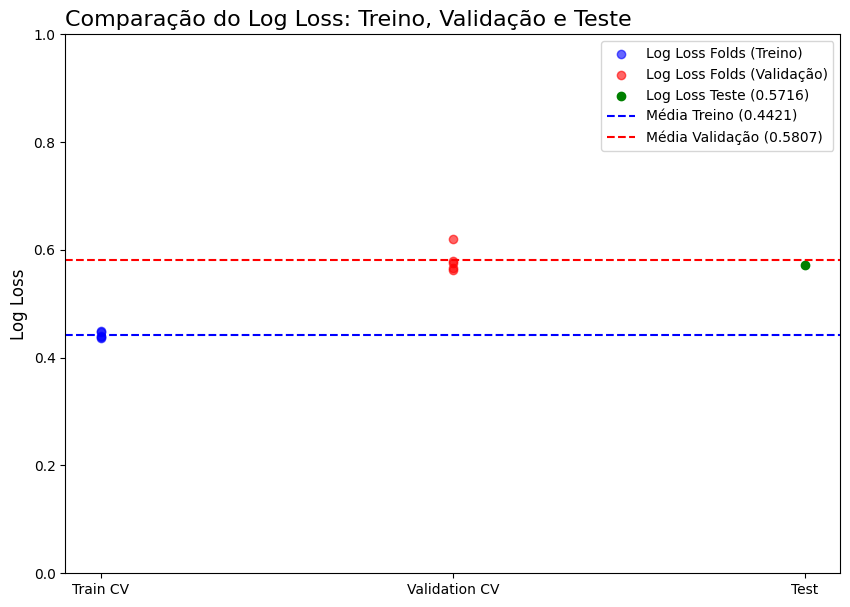

In [75]:
plt.figure(figsize=(10, 7))

labels = ['Train CV', 'Validation CV', 'Test']
train_losses = results_rf['train']['log_loss']
val_losses = results_rf['validation']['log_loss']
test_loss = test_metrics_rf['log_loss']

plt.scatter(y=train_losses, x=['Train CV']*N_SPLITS, color='blue', alpha=0.6, label='Log Loss Folds (Treino)')
plt.scatter(y=val_losses, x=['Validation CV']*N_SPLITS, color='red', alpha=0.6, label='Log Loss Folds (Validação)')
plt.scatter([2], [test_loss], color='green', label=f'Log Loss Teste ({test_loss:.4f})')

mean_train_loss = np.mean(train_losses)
mean_val_loss = np.mean(val_losses)

plt.axhline(y=mean_train_loss, color='blue', linestyle='--', label=f'Média Treino ({mean_train_loss:.4f})')
plt.axhline(y=mean_val_loss, color='red', linestyle='--', label=f'Média Validação ({mean_val_loss:.4f})')

plt.title('Comparação do Log Loss: Treino, Validação e Teste', fontsize=16, loc='left')
plt.ylabel('Log Loss', fontsize=12)

plt.xticks(range(len(labels)), labels)
plt.ylim(0, 1)
plt.legend()
plt.grid(False)
plt.show()

### Matriz de confusão

In [76]:
list(order_by_label)
order_by_label = ['Não evadiu', 'Evadiu']

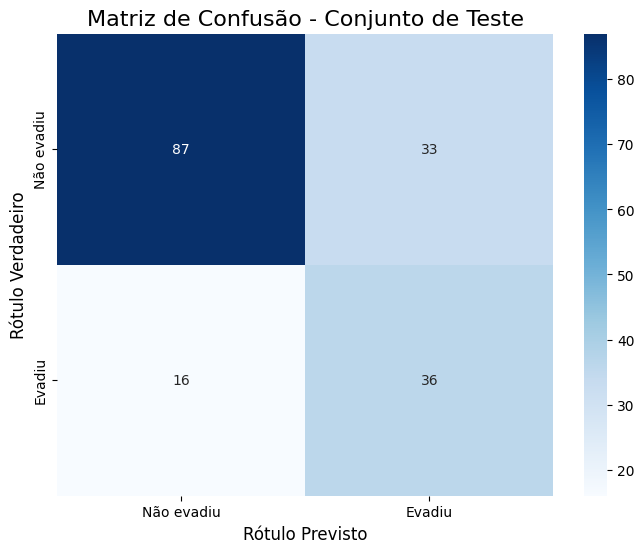

In [77]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(order_by_label), yticklabels=list(order_by_label))
plt.title('Matriz de Confusão - Conjunto de Teste', fontsize=16)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.show()

In [78]:
print(classification_report(y_test, y_pred, target_names=[str(c) for c in list(order_by_label)], digits=4))

              precision    recall  f1-score   support

  Não evadiu     0.8447    0.7250    0.7803       120
      Evadiu     0.5217    0.6923    0.5950        52

    accuracy                         0.7151       172
   macro avg     0.6832    0.7087    0.6877       172
weighted avg     0.7470    0.7151    0.7243       172



### Feature importance

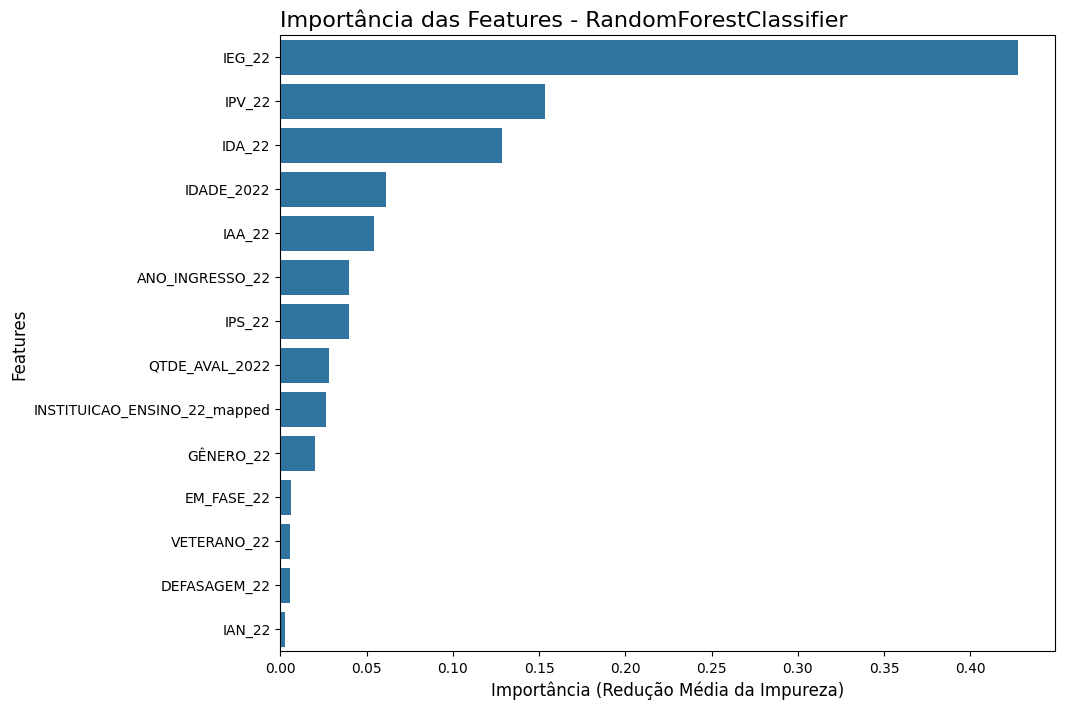

In [79]:
importances = model_rf.feature_importances_
feature_names = X_train.columns
feature_importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance_series, y=feature_importance_series.index)
plt.title('Importância das Features - RandomForestClassifier', fontsize=16, loc='left')
plt.xlabel('Importância (Redução Média da Impureza)', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.show()

### SHAP Values

In [80]:
explainer = shap.TreeExplainer(model_rf)

shap_values = explainer.shap_values(X_test_df)

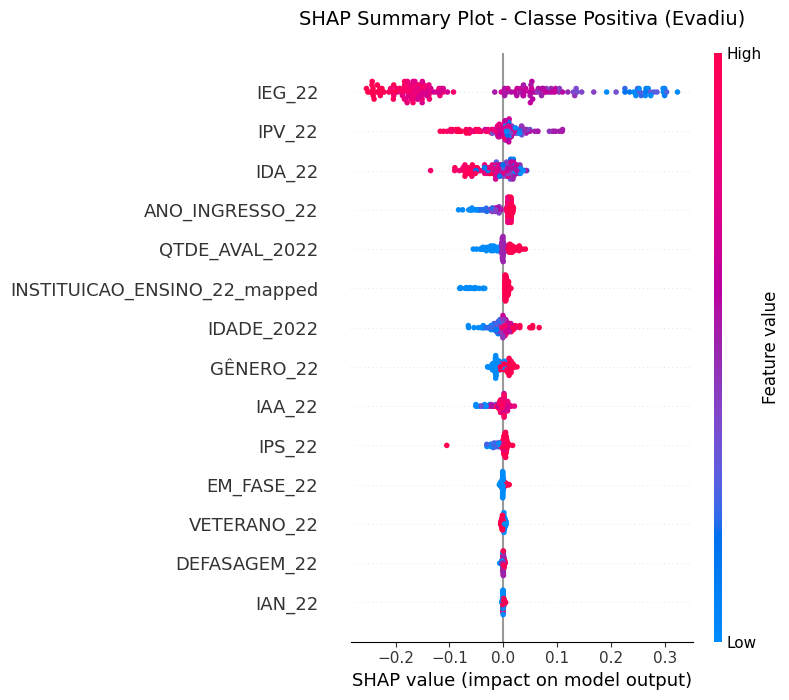

In [81]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,  
    plot_type="dot",  
    feature_names=X_test.columns.tolist(),
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot - Classe Positiva (Evadiu)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Modelagem - LightGBM

## Parâmetros e modelo

In [82]:
# Dicionário de parâmetros iniciais para LightGBM
RANDOM_STATE = 42

lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'n_estimators': 250,
    'learning_rate': 0.1,
    'max_depth': 3,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1,
    'min_data': 150,
}

lgbm_model = LGBMClassifier(**lgbm_params)

## Validação cruzada

In [83]:
results_lgb = perform_cross_validation(
    X_train=X_train,
    y_train=y_train,
    skf=skf,
    model=lgbm_model,
)


Processando Fold 1/5

Train      - Acc: 0.7382 | F1: 0.6453 | ROC-AUC: 0.8163
Validation - Acc: 0.6739 | F1: 0.5263 | ROC-AUC: 0.7242

Processando Fold 2/5

Train      - Acc: 0.7382 | F1: 0.6400 | ROC-AUC: 0.8143
Validation - Acc: 0.6739 | F1: 0.5455 | ROC-AUC: 0.7082

Processando Fold 3/5

Train      - Acc: 0.7527 | F1: 0.6531 | ROC-AUC: 0.8196
Validation - Acc: 0.6667 | F1: 0.5490 | ROC-AUC: 0.6926

Processando Fold 4/5

Train      - Acc: 0.7459 | F1: 0.6429 | ROC-AUC: 0.8094
Validation - Acc: 0.7226 | F1: 0.6122 | ROC-AUC: 0.7405

Processando Fold 5/5

Train      - Acc: 0.7296 | F1: 0.6247 | ROC-AUC: 0.8103
Validation - Acc: 0.7080 | F1: 0.5918 | ROC-AUC: 0.7111

✅ Validação Cruzada concluída!


In [84]:
print("\n--- Resultados Finais da Validação Cruzada (Média ± Desvio Padrão) ---")

for metric_name in results_lgb['validation']:
    mean_train = np.mean(results_lgb['train'][metric_name])
    std_train = np.std(results_lgb['train'][metric_name])
    mean_val = np.mean(results_lgb['validation'][metric_name])
    std_val = np.std(results_lgb['validation'][metric_name])

    print(f"\nMétrica: {metric_name.replace('_', ' ').title()}")
    print(f"  - Treino     : {mean_train:.4f} ± {std_train:.4f}")
    print(f"  - Validação  : {mean_val:.4f} ± {std_val:.4f}")


--- Resultados Finais da Validação Cruzada (Média ± Desvio Padrão) ---

Métrica: Accuracy
  - Treino     : 0.7409 ± 0.0078
  - Validação  : 0.6890 ± 0.0221

Métrica: F1 Score
  - Treino     : 0.6412 ± 0.0093
  - Validação  : 0.5650 ± 0.0319

Métrica: Recall
  - Treino     : 0.7657 ± 0.0159
  - Validação  : 0.6688 ± 0.0480

Métrica: Precision
  - Treino     : 0.5517 ± 0.0100
  - Validação  : 0.4894 ± 0.0237

Métrica: Log Loss
  - Treino     : 0.5360 ± 0.0041
  - Validação  : 0.6155 ± 0.0186

Métrica: Roc Auc
  - Treino     : 0.8140 ± 0.0038
  - Validação  : 0.7153 ± 0.0161

Métrica: Pr Auc
  - Treino     : 0.6213 ± 0.0099
  - Validação  : 0.4942 ± 0.0437


## Testando modelo

In [85]:
feature_names = X_train.columns

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [86]:
lgbm_model = LGBMClassifier(**lgbm_params)

print("Treinando o modelo final com os dados de treino completos...")
lgbm_model.fit(X_train_scaled, y_train) 

print("Avaliando o modelo no conjunto de teste...")
y_pred = lgbm_model.predict(X_test_scaled)
y_proba = lgbm_model.predict_proba(X_test_scaled)

Treinando o modelo final com os dados de treino completos...
Avaliando o modelo no conjunto de teste...


## Métricas e visualizações

In [87]:
# Extrair probabilidade da classe positiva (coluna 1)
y_proba_pos = y_proba[:, 1]

# Calcular métricas para classificação binária
test_metrics_lgb = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred, pos_label=1),  
    'recall': recall_score(y_test, y_pred, pos_label=1),  # Sensibilidade
    'precision': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
    'log_loss': log_loss(y_test, y_proba),  
    'roc_auc': roc_auc_score(y_test, y_proba_pos),  
}

print("\n📊 MÉTRICAS NO CONJUNTO DE TESTE:")
print("="*50)
for name, value in test_metrics_lgb.items():
    print(f"  {name.replace('_', ' ').title():15s}: {value:.4f}")


📊 MÉTRICAS NO CONJUNTO DE TESTE:
  Accuracy       : 0.7209
  F1 Score       : 0.6190
  Recall         : 0.7500
  Precision      : 0.5270
  Log Loss       : 0.5739
  Roc Auc        : 0.7689


### Scatter plot do logloss

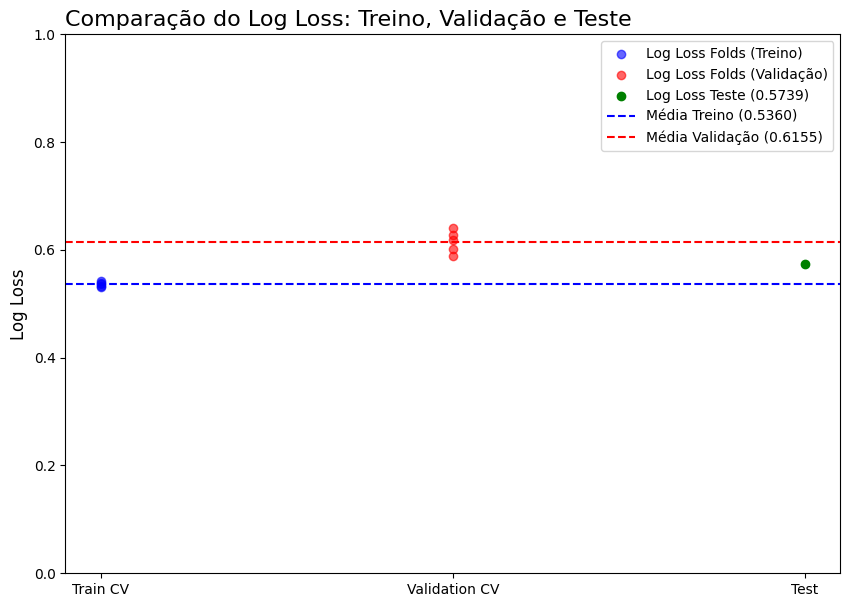

In [88]:
plt.figure(figsize=(10, 7))

labels = ['Train CV', 'Validation CV', 'Test']
train_losses = results_lgb['train']['log_loss']
val_losses = results_lgb['validation']['log_loss']
test_loss = test_metrics_lgb['log_loss']

plt.scatter(y=train_losses, x=['Train CV']*N_SPLITS, color='blue', alpha=0.6, label='Log Loss Folds (Treino)')
plt.scatter(y=val_losses, x=['Validation CV']*N_SPLITS, color='red', alpha=0.6, label='Log Loss Folds (Validação)')
plt.scatter([2], [test_loss], color='green', label=f'Log Loss Teste ({test_loss:.4f})')

mean_train_loss = np.mean(train_losses)
mean_val_loss = np.mean(val_losses)

plt.axhline(y=mean_train_loss, color='blue', linestyle='--', label=f'Média Treino ({mean_train_loss:.4f})')
plt.axhline(y=mean_val_loss, color='red', linestyle='--', label=f'Média Validação ({mean_val_loss:.4f})')

plt.title('Comparação do Log Loss: Treino, Validação e Teste', fontsize=16, loc='left')
plt.ylabel('Log Loss', fontsize=12)

plt.xticks(range(len(labels)), labels)
plt.ylim(0, 1)
plt.legend()
plt.grid(False)
plt.show()

### Matriz de confusão

In [89]:
list(order_by_label)
order_by_label = ['Não evadiu', 'Evadiu']

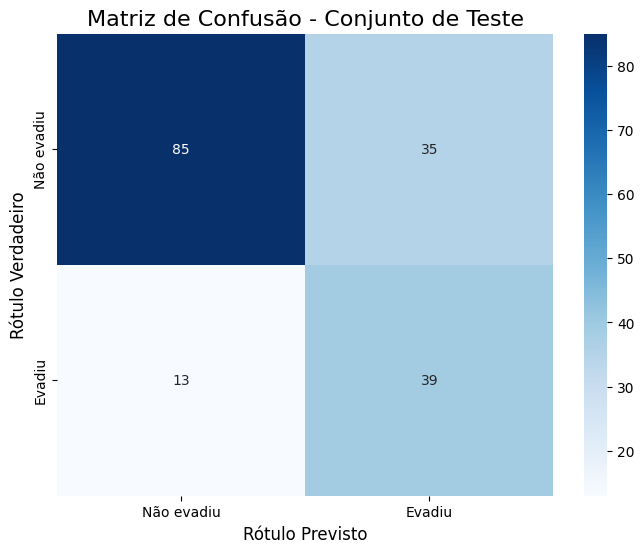

In [90]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(order_by_label), yticklabels=list(order_by_label))
plt.title('Matriz de Confusão - Conjunto de Teste', fontsize=16)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.show()

In [91]:
print(classification_report(y_test, y_pred, target_names=[str(c) for c in list(order_by_label)], digits=4))

              precision    recall  f1-score   support

  Não evadiu     0.8673    0.7083    0.7798       120
      Evadiu     0.5270    0.7500    0.6190        52

    accuracy                         0.7209       172
   macro avg     0.6972    0.7292    0.6994       172
weighted avg     0.7645    0.7209    0.7312       172



### Feature importance

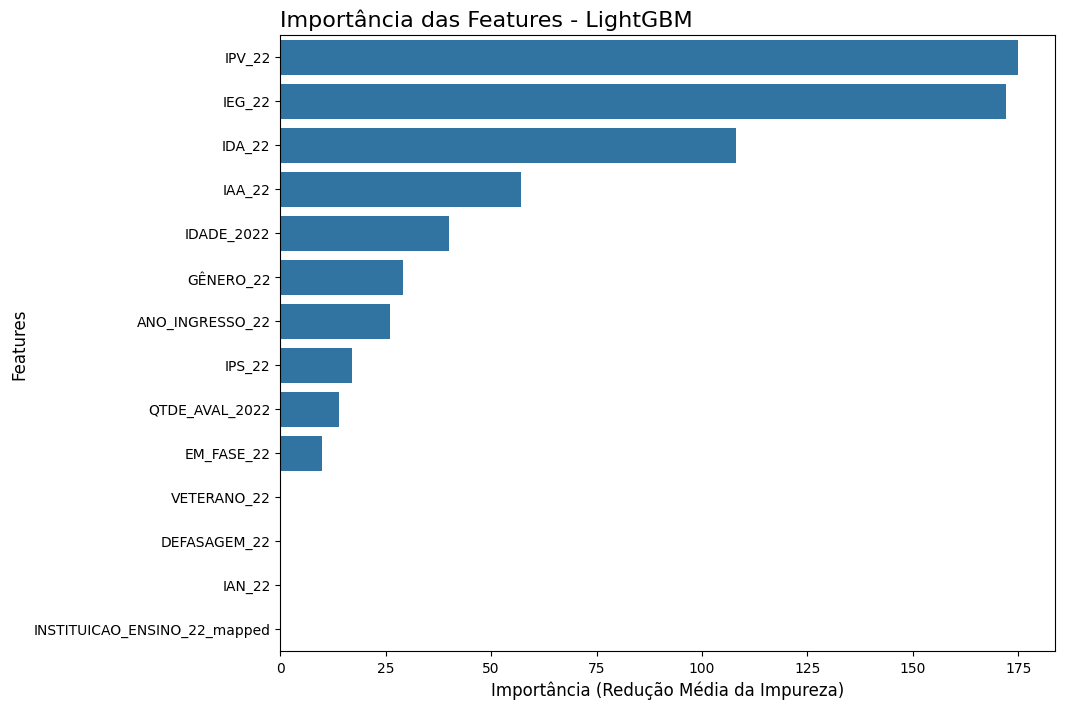

In [92]:
importances = lgbm_model.feature_importances_
feature_names = X_train.columns
feature_importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance_series, y=feature_importance_series.index)
plt.title('Importância das Features - LightGBM', fontsize=16, loc='left')
plt.xlabel('Importância (Redução Média da Impureza)', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.show()

### SHAP Values

In [93]:
explainer = shap.TreeExplainer(lgbm_model)

shap_explanation = explainer(X_test_scaled)

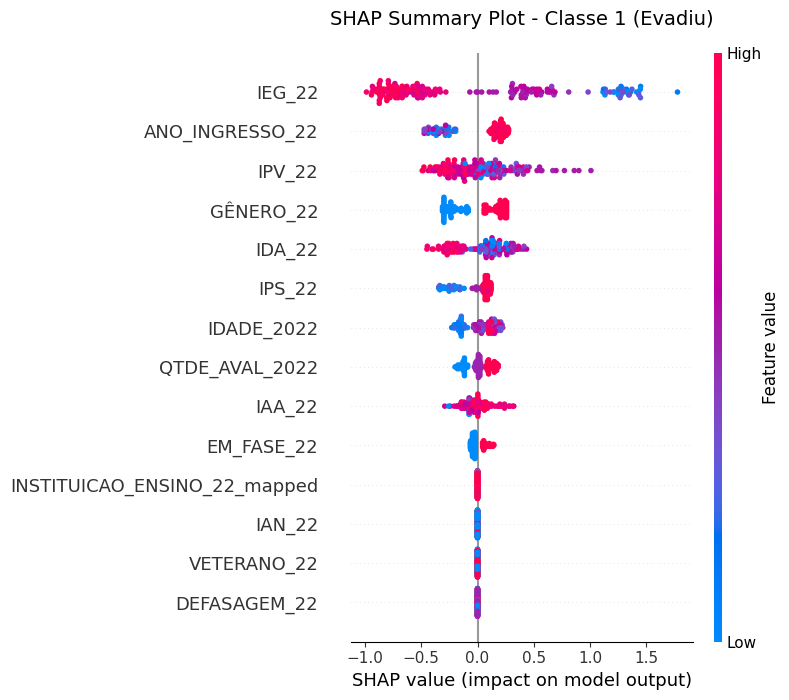

In [94]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_explanation,
    X_test_scaled,
    show=False
)
plt.title('SHAP Summary Plot - Classe 1 (Evadiu)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()